# Mouse Behavior Detection: ULTRA Comprehensive EDA

This notebook performs deep exploratory data analysis on the MABe mouse behavior dataset.
Based on initial findings and extends with advanced statistical and visual analyses.

## 0. Setup and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

# Set visual style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["figure.dpi"] = 120

# Create output directory
figures_dir = Path("eda/figures")
figures_dir.mkdir(parents=True, exist_ok=True)
print(f"📁 Figures will be saved to: {figures_dir.absolute()}")

# File paths
base_path = Path("data/MABe-mouse-behavior-detection")
train_csv = base_path / "train.csv"
test_csv = base_path / "test.csv"

📁 Figures will be saved to: /home/mingjia-guan/workspaces/MABe-2025/eda/figures


## 1. Data Loading and Initial Profiling

In [2]:
# Load main datasets
train = pd.read_csv(train_csv)
test = pd.read_csv(test_csv)

print("=" * 80)
print("DATASET DIMENSIONS")
print("=" * 80)
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nMemory usage:")
print(f"  Train: {train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"  Test: {test.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

DATASET DIMENSIONS
Train shape: (8789, 38)
Test shape: (1, 38)

Memory usage:
  Train: 13.56 MB
  Test: 0.00 MB


In [3]:
display(train.head())
display(train.info())
display(train.describe())

,lab_id,video_id,mouse1_strain,mouse1_color,mouse1_sex,mouse1_id,mouse1_age,mouse1_condition,mouse2_strain,mouse2_color,...,pix_per_cm_approx,video_width_pix,video_height_pix,arena_width_cm,arena_height_cm,arena_shape,arena_type,body_parts_tracked,behaviors_labeled,tracking_method
0,AdaptableSnail,44566106,CD-1 (ICR),white,male,10.0,8-12 weeks,wireless device,CD-1 (ICR),white,...,16.0,1228,1068,60.0,60.0,square,familiar,"[""body_center"", ""ear_left"", ""ear_right"", ""head...","[""mouse1,mouse2,approach"", ""mouse1,mouse2,atta...",DeepLabCut
1,AdaptableSnail,143861384,CD-1 (ICR),white,male,3.0,8-12 weeks,NaN,CD-1 (ICR),white,...,9.7,968,608,60.0,60.0,square,familiar,"[""body_center"", ""ear_left"", ""ear_right"", ""late...","[""mouse1,mouse2,approach"", ""mouse1,mouse2,atta...",DeepLabCut
2,AdaptableSnail,209576908,CD-1 (ICR),white,male,7.0,8-12 weeks,NaN,CD-1 (ICR),white,...,16.0,1266,1100,60.0,60.0,square,familiar,"[""body_center"", ""ear_left"", ""ear_right"", ""late...","[""mouse1,mouse2,approach"", ""mouse1,mouse2,atta...",DeepLabCut
3,AdaptableSnail,278643799,CD-1 (ICR),white,male,11.0,8-12 weeks,wireless device,CD-1 (ICR),white,...,16.0,1224,1100,60.0,60.0,square,familiar,"[""body_center"", ""ear_left"", ""ear_right"", ""head...","[""mouse1,mouse2,approach"", ""mouse1,mouse2,atta...",DeepLabCut
4,AdaptableSnail,351967631,CD-1 (ICR),white,male,14.0,8-12 weeks,NaN,CD-1 (ICR),white,...,16.0,1204,1068,60.0,60.0,square,familiar,"[""body_center"", ""ear_left"", ""ear_right"", ""late...","[""mouse1,mouse2,approach"", ""mouse1,mouse2,atta...",DeepLabCut


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8789 entries, 0 to 8788
Data columns (total 38 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   lab_id              8789 non-null   object 
 1   video_id            8789 non-null   int64  
 2   mouse1_strain       8789 non-null   object 
 3   mouse1_color        8789 non-null   object 
 4   mouse1_sex          8779 non-null   object 
 5   mouse1_id           816 non-null    float64
 6   mouse1_age          8140 non-null   object 
 7   mouse1_condition    8229 non-null   object 
 8   mouse2_strain       8789 non-null   object 
 9   mouse2_color        8789 non-null   object 
 10  mouse2_sex          8742 non-null   object 
 11  mouse2_id           108 non-null    float64
 12  mouse2_age          8140 non-null   object 
 13  mouse2_condition    7991 non-null   object 
 14  mouse3_strain       7943 non-null   object 
 15  mouse3_color        7943 non-null   object 
 16  mouse3

None

,video_id,mouse1_id,mouse2_id,mouse3_id,mouse4_id,frames_per_second,video_duration_sec,pix_per_cm_approx,video_width_pix,video_height_pix,arena_width_cm,arena_height_cm
count,8.789000e+03,816.000000,108.000000,17.000000,10.000000,8789.000000,8789.000000,8789.000000,8789.000000,8789.000000,8789.000000,8789.000000
mean,1.072697e+09,24.571078,19.518519,35.588235,48.400000,30.402648,134.647855,12.440189,813.654227,790.369667,50.457856,49.299670
std,6.209820e+08,22.444201,11.660687,4.542285,2.951459,6.434061,637.123844,3.405194,109.410878,133.869821,7.580842,10.705873
min,9.603000e+03,1.000000,1.000000,29.000000,44.000000,10.000000,19.000000,5.500000,300.000000,194.000000,12.700000,12.000000
25%,5.380940e+08,6.000000,12.000000,32.000000,46.250000,30.000000,60.000000,11.700000,800.000000,800.000000,52.000000,52.000000
50%,1.072003e+09,15.000000,17.000000,35.000000,48.000000,30.000000,60.000000,11.700000,800.000000,800.000000,52.000000,52.000000
75%,1.615401e+09,38.000000,24.250000,39.000000,51.000000,30.000000,60.000000,11.700000,800.000000,800.000000,52.000000,52.000000
max,2.147479e+09,80.000000,53.000000,42.000000,52.000000,120.020000,19801.000000,65.000000,2048.000000,2056.000000,120.000000,120.000000


## 2. Missing Data Analysis


MISSING DATA SUMMARY


,Column,Missing_Count,Missing_Pct,Data_Type
25,mouse4_condition,8786,99.97,object
21,mouse4_color,8779,99.89,object
22,mouse4_sex,8779,99.89,object
20,mouse4_strain,8779,99.89,object
23,mouse4_id,8779,99.89,float64
24,mouse4_age,8778,99.87,object
17,mouse3_id,8772,99.81,float64
11,mouse2_id,8681,98.77,float64
5,mouse1_id,7973,90.72,float64
36,behaviors_labeled,7941,90.35,object


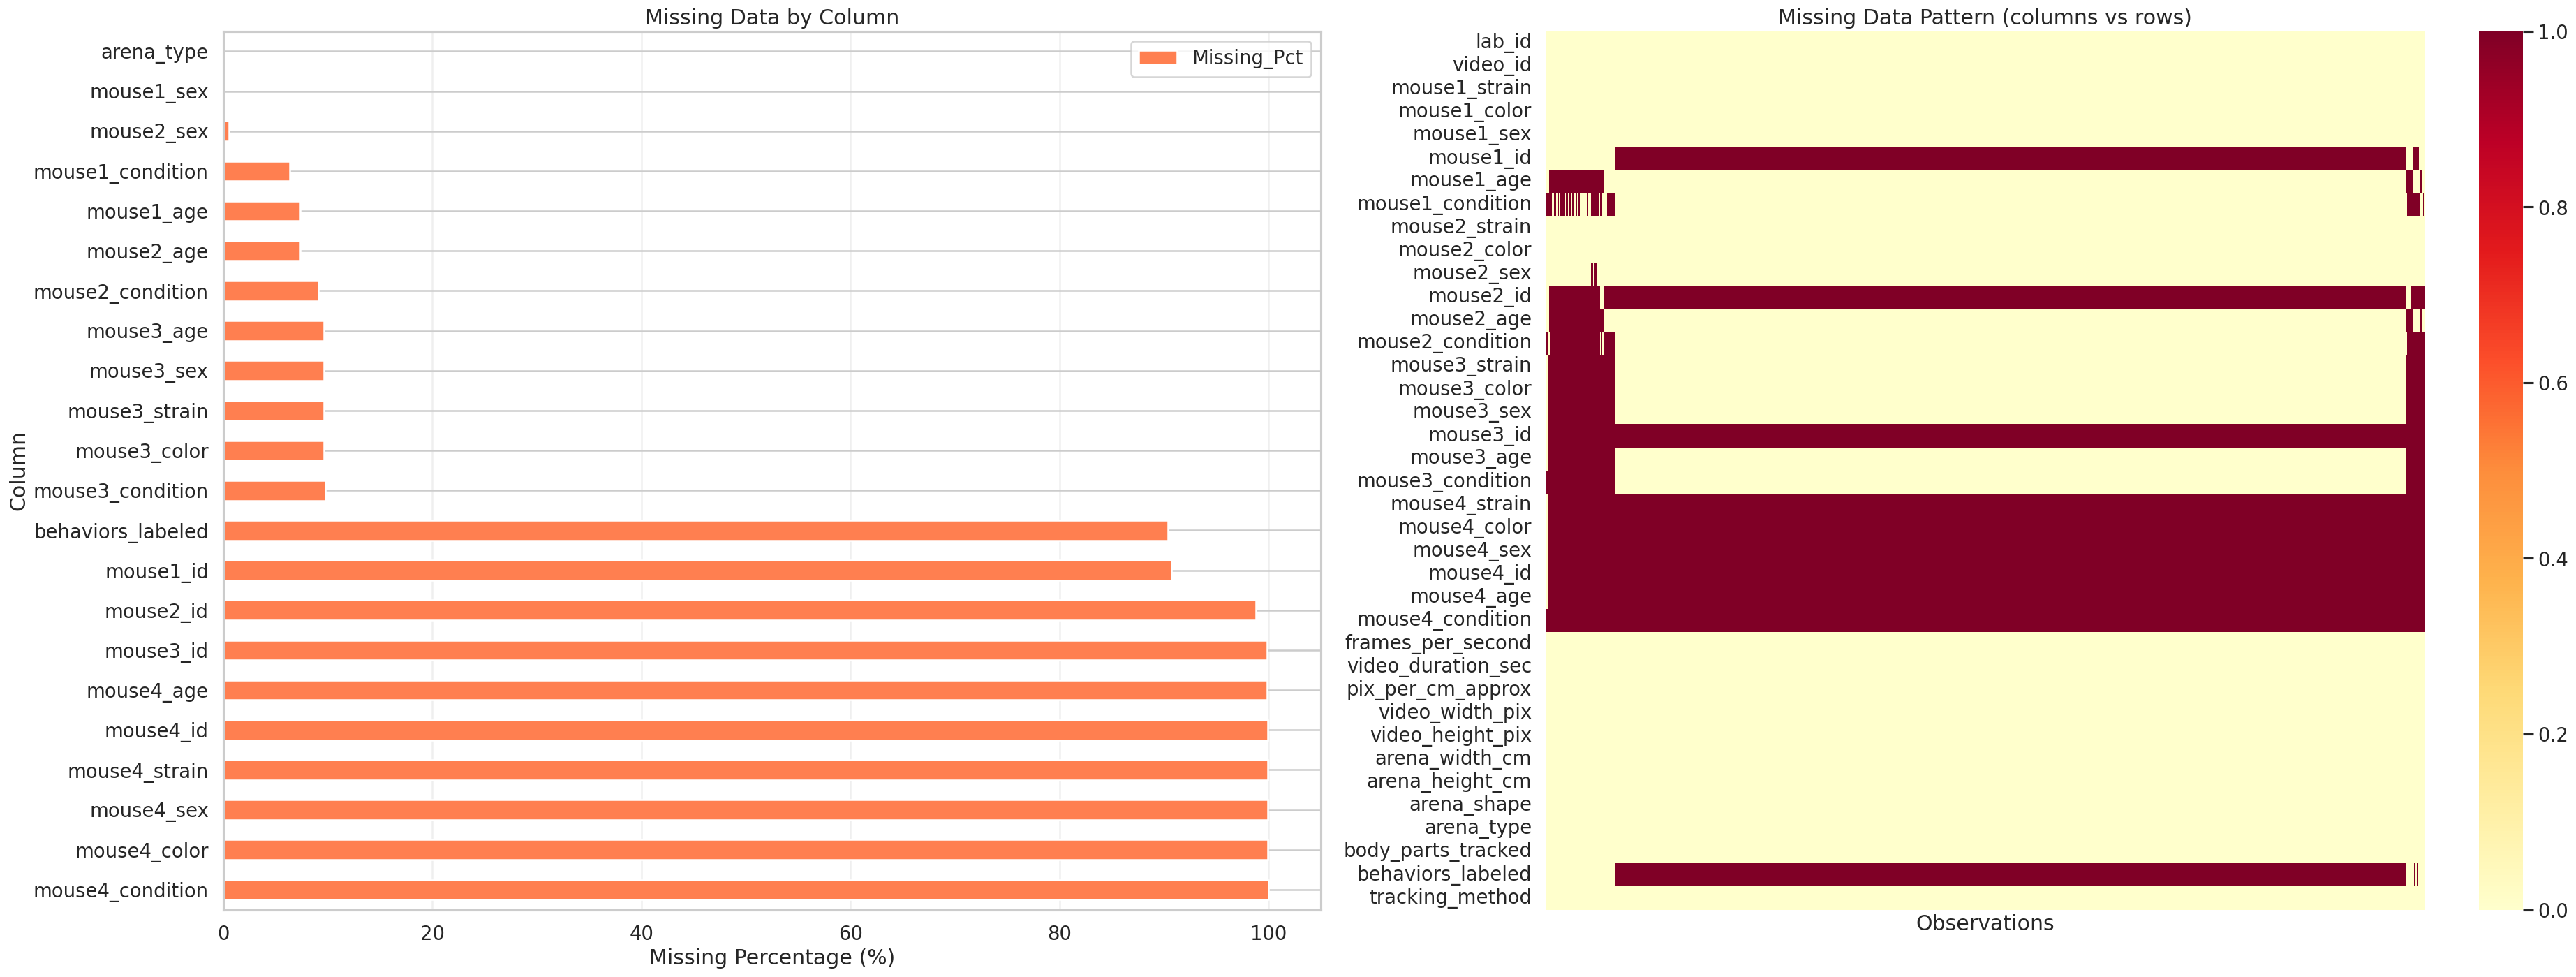

In [4]:
# Comprehensive missing data analysis
missing_df = pd.DataFrame({
    'Column': train.columns,
    'Missing_Count': train.isnull().sum().values,
    'Missing_Pct': (train.isnull().sum().values / len(train) * 100).round(2),
    'Data_Type': train.dtypes.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Pct', ascending=False)

print("\n" + "=" * 80)
print("MISSING DATA SUMMARY")
print("=" * 80)
display(missing_df)

# Visualize missing data patterns
fig, axes = plt.subplots(1, 2, figsize=(32, 12))

# Missing data bar plot
ax = axes[0]
missing_df.plot(x='Column', y='Missing_Pct', kind='barh', ax=ax, color='coral')
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Data by Column')
ax.grid(axis='x', alpha=0.3)

# Missing data heatmap
ax = axes[1]
missing_matrix = train.isnull().astype(int)
sns.heatmap(missing_matrix.T, cbar=True, yticklabels=True, xticklabels=False, 
            cmap='YlOrRd', ax=ax)
ax.set_title('Missing Data Pattern (columns vs rows)')
ax.set_xlabel('Observations')

plt.tight_layout()
plt.savefig(figures_dir / "missing_data_analysis.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 3. Lab and Experimental Design Analysis


LAB STATISTICS


,video_id_count,video_duration_sec_mean,video_duration_sec_std,video_duration_sec_sum,frames_per_second_mean,arena_width_cm_mean
lab_id,,,,,,
MABe22_keypoints,5320,60.00,0.00,319200.0,30.00,52.00
MABe22_movies,2606,60.00,0.00,156360.0,30.00,52.00
CalMS21_supplemental,297,622.29,306.63,184819.9,30.00,35.00
CalMS21_task1,101,323.80,267.49,32704.3,30.00,35.00
CalMS21_task2,76,654.09,164.37,49710.6,30.00,35.00
SparklingTapir,69,259.91,249.15,17934.0,60.14,20.32
JovialSwallow,52,900.00,0.00,46800.0,10.00,15.00
PleasantMeerkat,36,600.00,0.00,21600.0,45.00,120.00
InvincibleJellyfish,33,571.23,2.88,18850.7,30.00,28.00


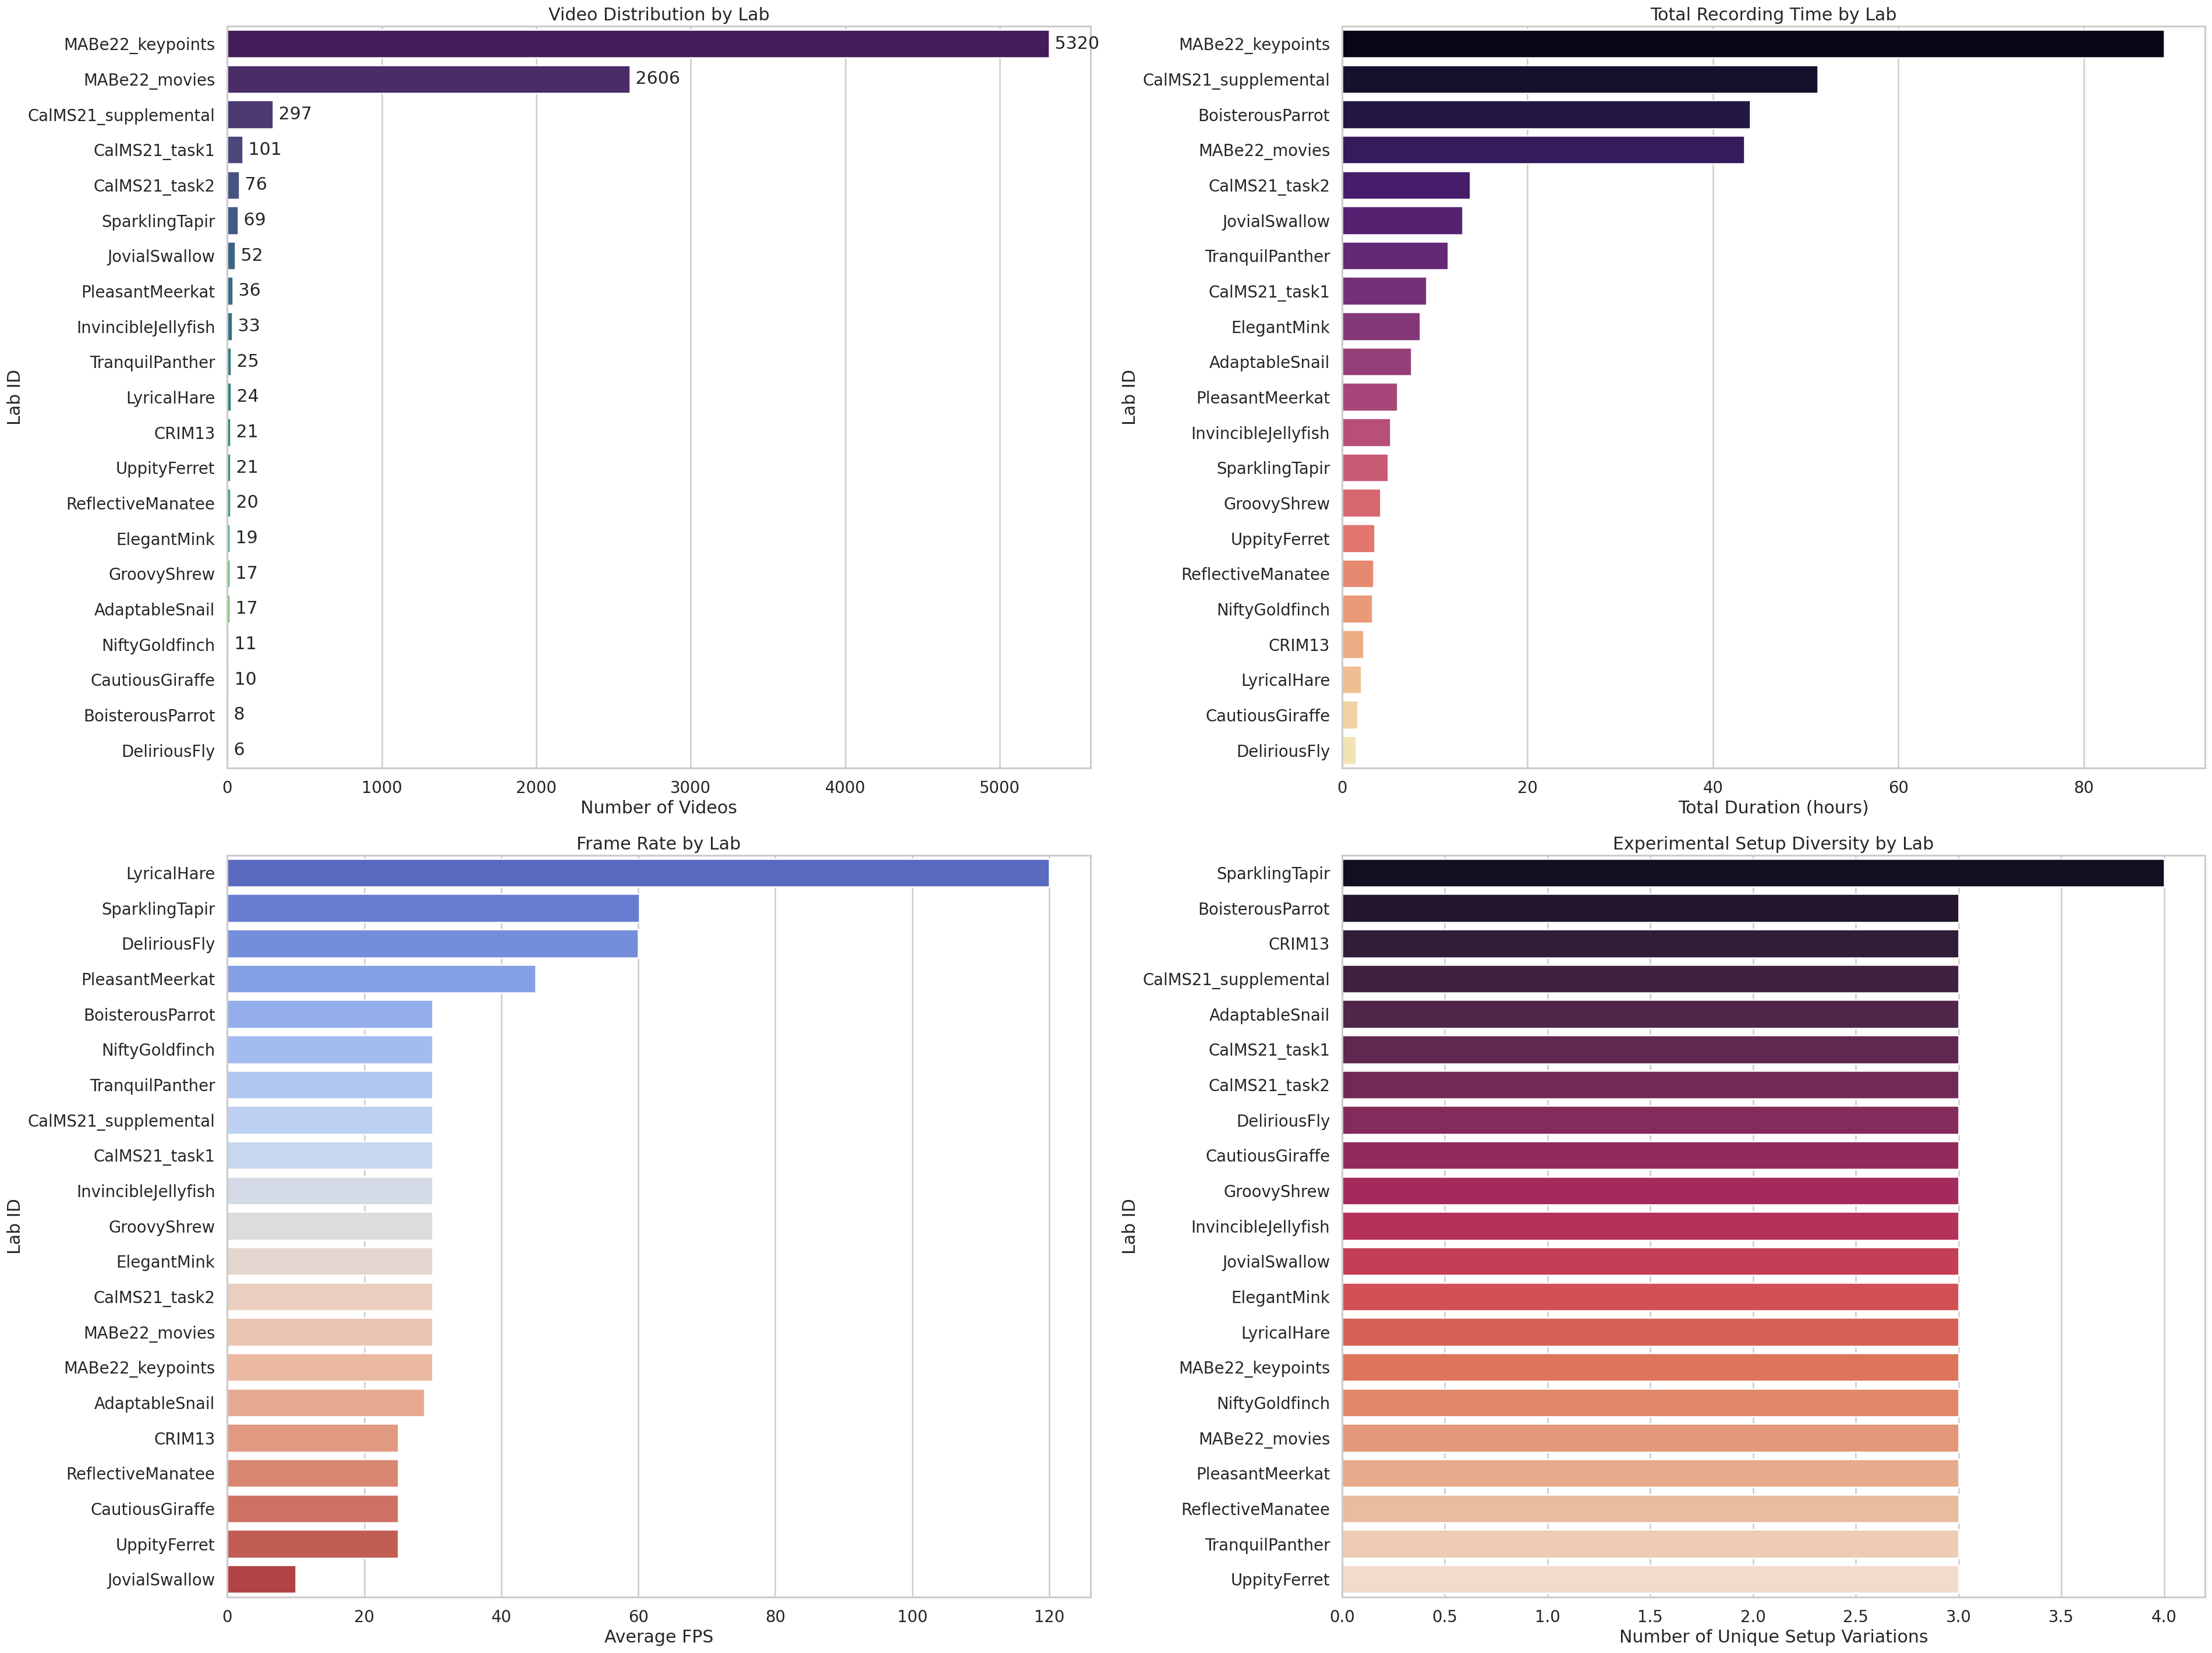

In [5]:
# Lab distribution with statistics
lab_stats = train.groupby('lab_id').agg({
    'video_id': 'count',
    'video_duration_sec': ['mean', 'std', 'sum'],
    'frames_per_second': 'mean',
    'arena_width_cm': 'mean'
}).round(2)
lab_stats.columns = ['_'.join(col).strip() for col in lab_stats.columns.values]
lab_stats = lab_stats.sort_values('video_id_count', ascending=False)

print("\n" + "=" * 80)
print("LAB STATISTICS")
print("=" * 80)
display(lab_stats)

# Enhanced lab visualization
fig, axes = plt.subplots(2, 2, figsize=(32, 24))

# Lab video counts
ax = axes[0, 0]
lab_counts = train['lab_id'].value_counts()
sns.barplot(x=lab_counts.values, y=lab_counts.index, ax=ax, palette='viridis')
ax.set_xlabel('Number of Videos')
ax.set_ylabel('Lab ID')
ax.set_title('Video Distribution by Lab')
for i, v in enumerate(lab_counts.values):
    ax.text(v, i, f' {v}', va='center')

# Total video duration by lab
ax = axes[0, 1]
duration_by_lab = train.groupby('lab_id')['video_duration_sec'].sum().sort_values(ascending=False)
sns.barplot(x=duration_by_lab.values / 3600, y=duration_by_lab.index, ax=ax, palette='magma')
ax.set_xlabel('Total Duration (hours)')
ax.set_ylabel('Lab ID')
ax.set_title('Total Recording Time by Lab')

# Average FPS by lab
ax = axes[1, 0]
fps_by_lab = train.groupby('lab_id')['frames_per_second'].mean().sort_values(ascending=False)
sns.barplot(x=fps_by_lab.values, y=fps_by_lab.index, ax=ax, palette='coolwarm')
ax.set_xlabel('Average FPS')
ax.set_ylabel('Lab ID')
ax.set_title('Frame Rate by Lab')

# Unique experimental setups per lab
ax = axes[1, 1]
setup_diversity = train.groupby('lab_id').agg({
    'arena_type': 'nunique',
    'arena_shape': 'nunique',
    'tracking_method': 'nunique'
}).sum(axis=1).sort_values(ascending=False)
sns.barplot(x=setup_diversity.values, y=setup_diversity.index, ax=ax, palette='rocket')
ax.set_xlabel('Number of Unique Setup Variations')
ax.set_ylabel('Lab ID')
ax.set_title('Experimental Setup Diversity by Lab')

plt.tight_layout()
plt.savefig(figures_dir / "lab_comprehensive_analysis.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 4. Video Properties - Advanced Distributions

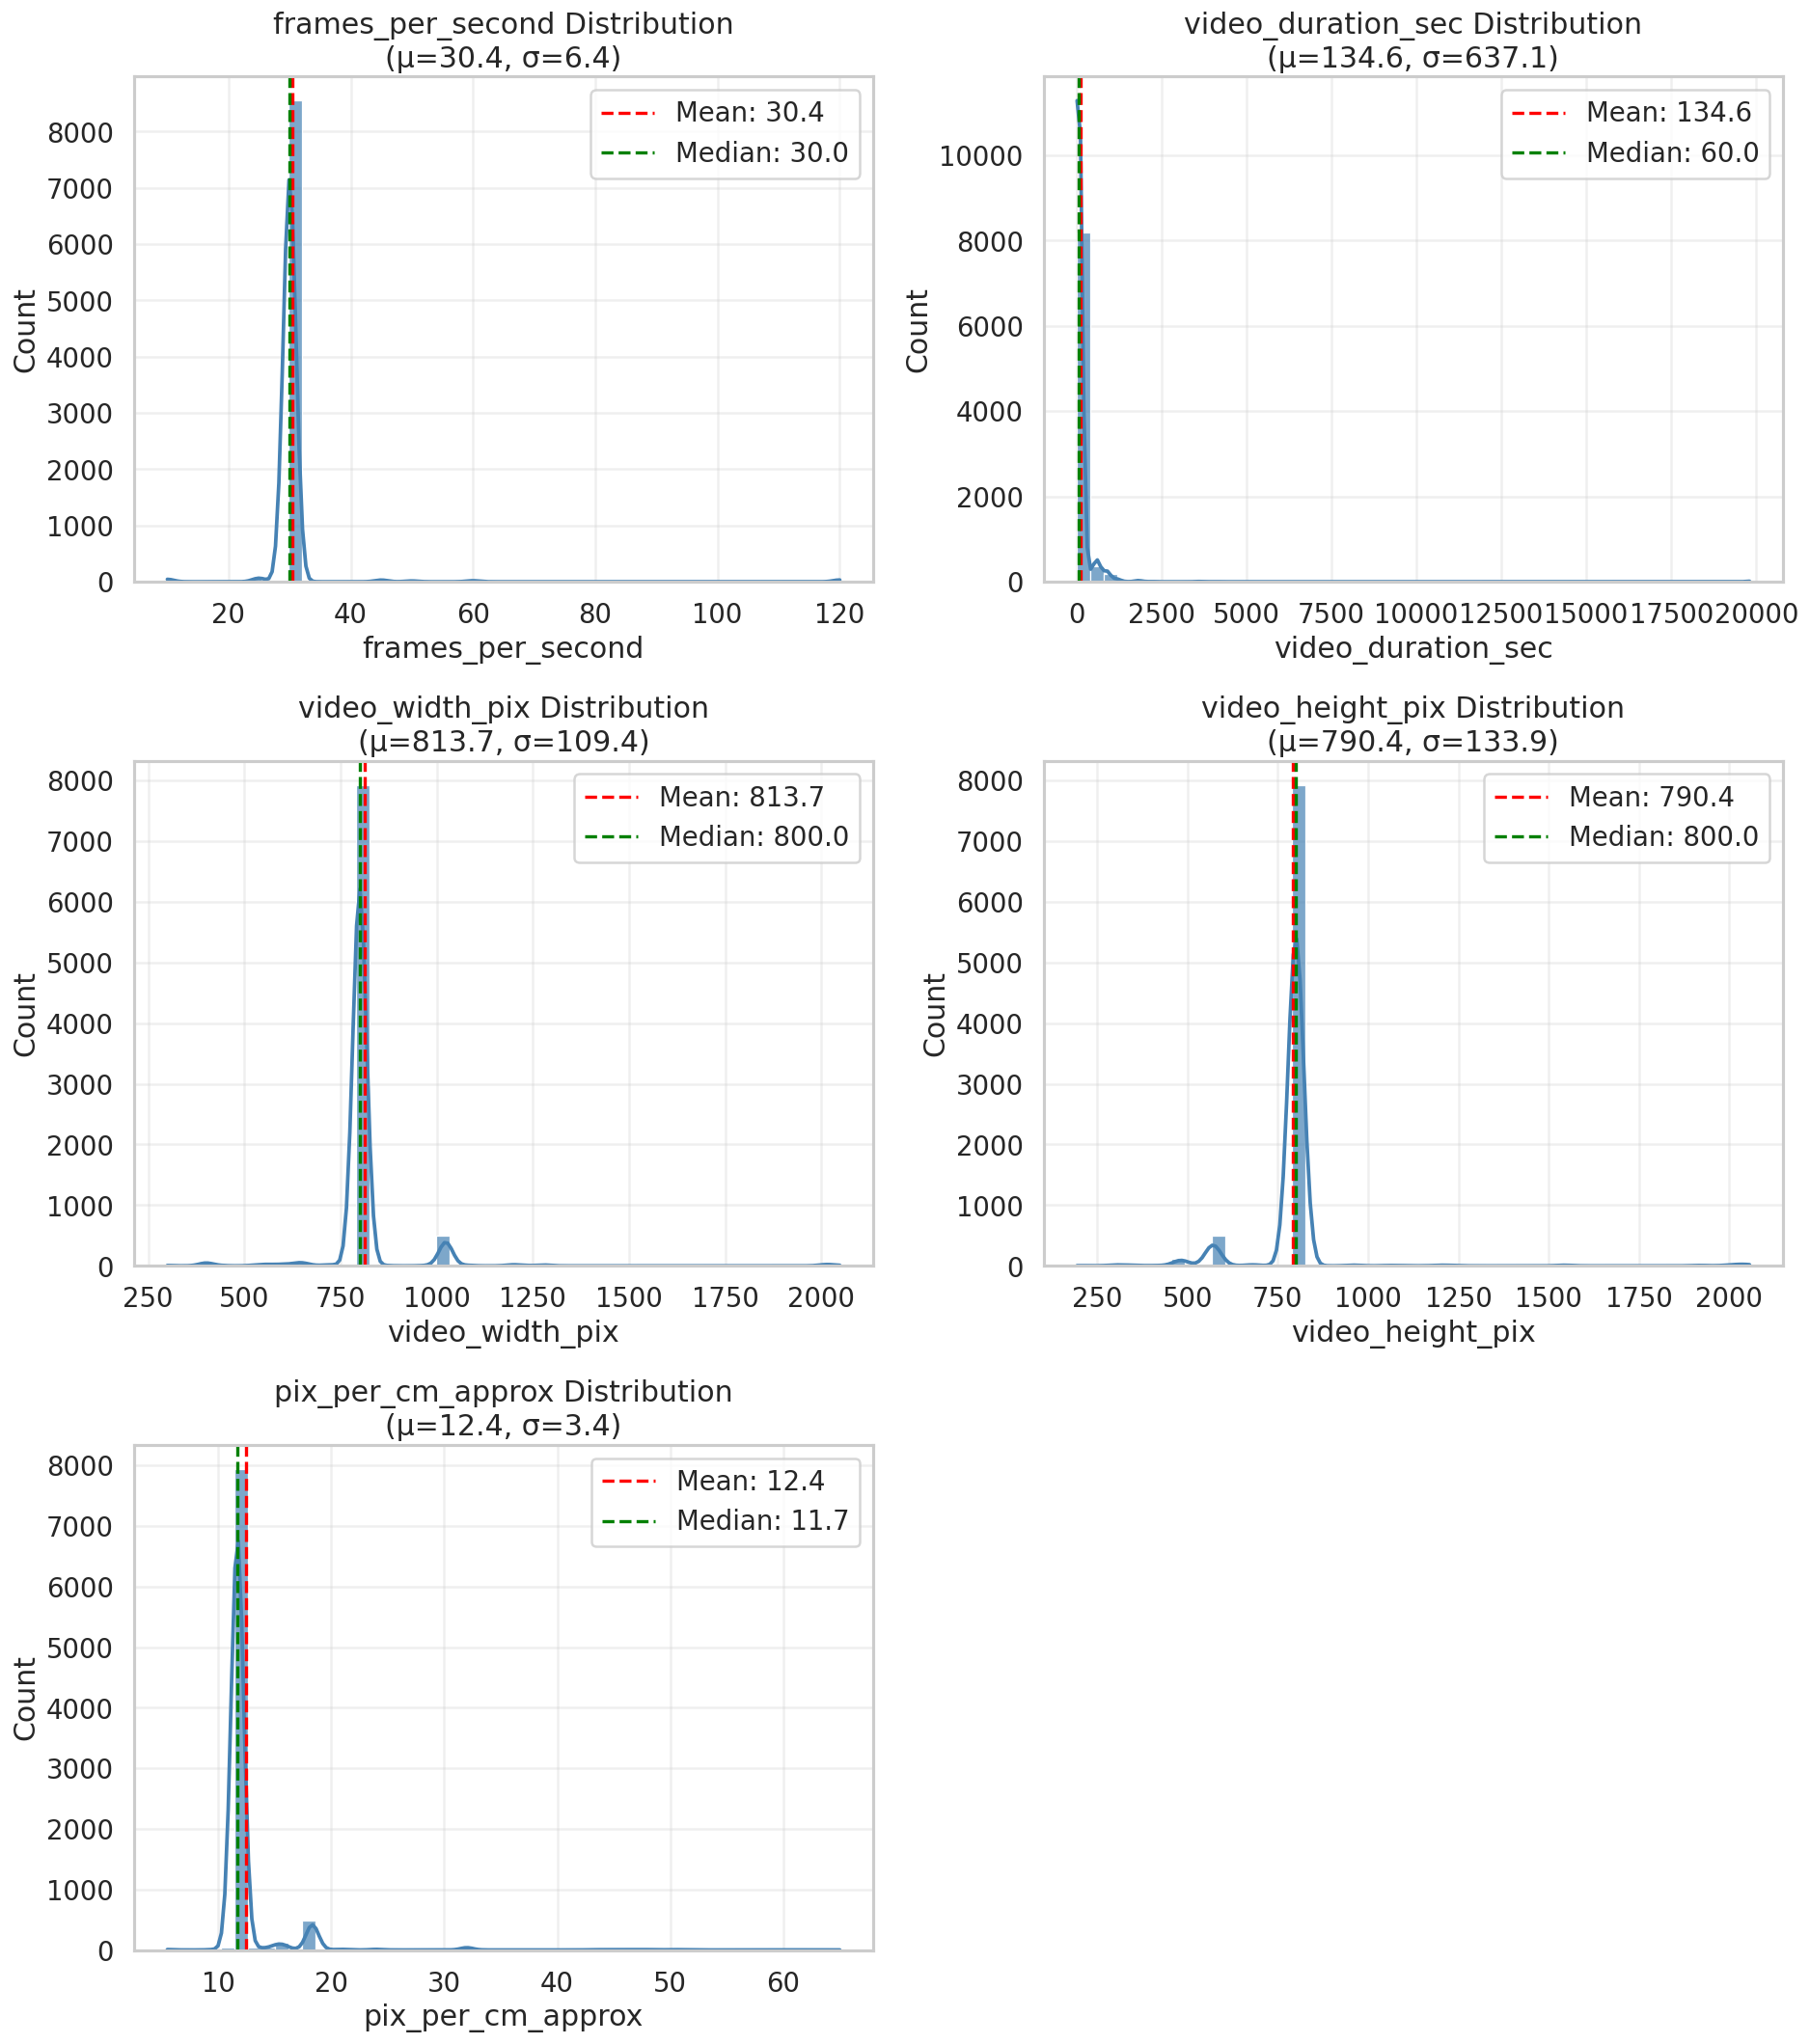

In [6]:
# Advanced video properties analysis
video_props = ['frames_per_second', 'video_duration_sec', 'video_width_pix', 
               'video_height_pix', 'pix_per_cm_approx']

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, col in enumerate(video_props):
    ax = axes[idx]
    data = train[col].dropna()

    # Histogram with KDE
    sns.histplot(data, kde=True, bins=50, ax=ax, color='steelblue', alpha=0.7)

    # Add statistics
    mean_val = data.mean()
    median_val = data.median()
    std_val = data.std()

    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')

    ax.set_title(f'{col} Distribution\n(μ={mean_val:.1f}, σ={std_val:.1f})')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(alpha=0.3)

# Remove extra subplot
axes[-1].remove()

plt.tight_layout()
plt.savefig(figures_dir / "video_properties_advanced.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 5. Arena Configuration Analysis

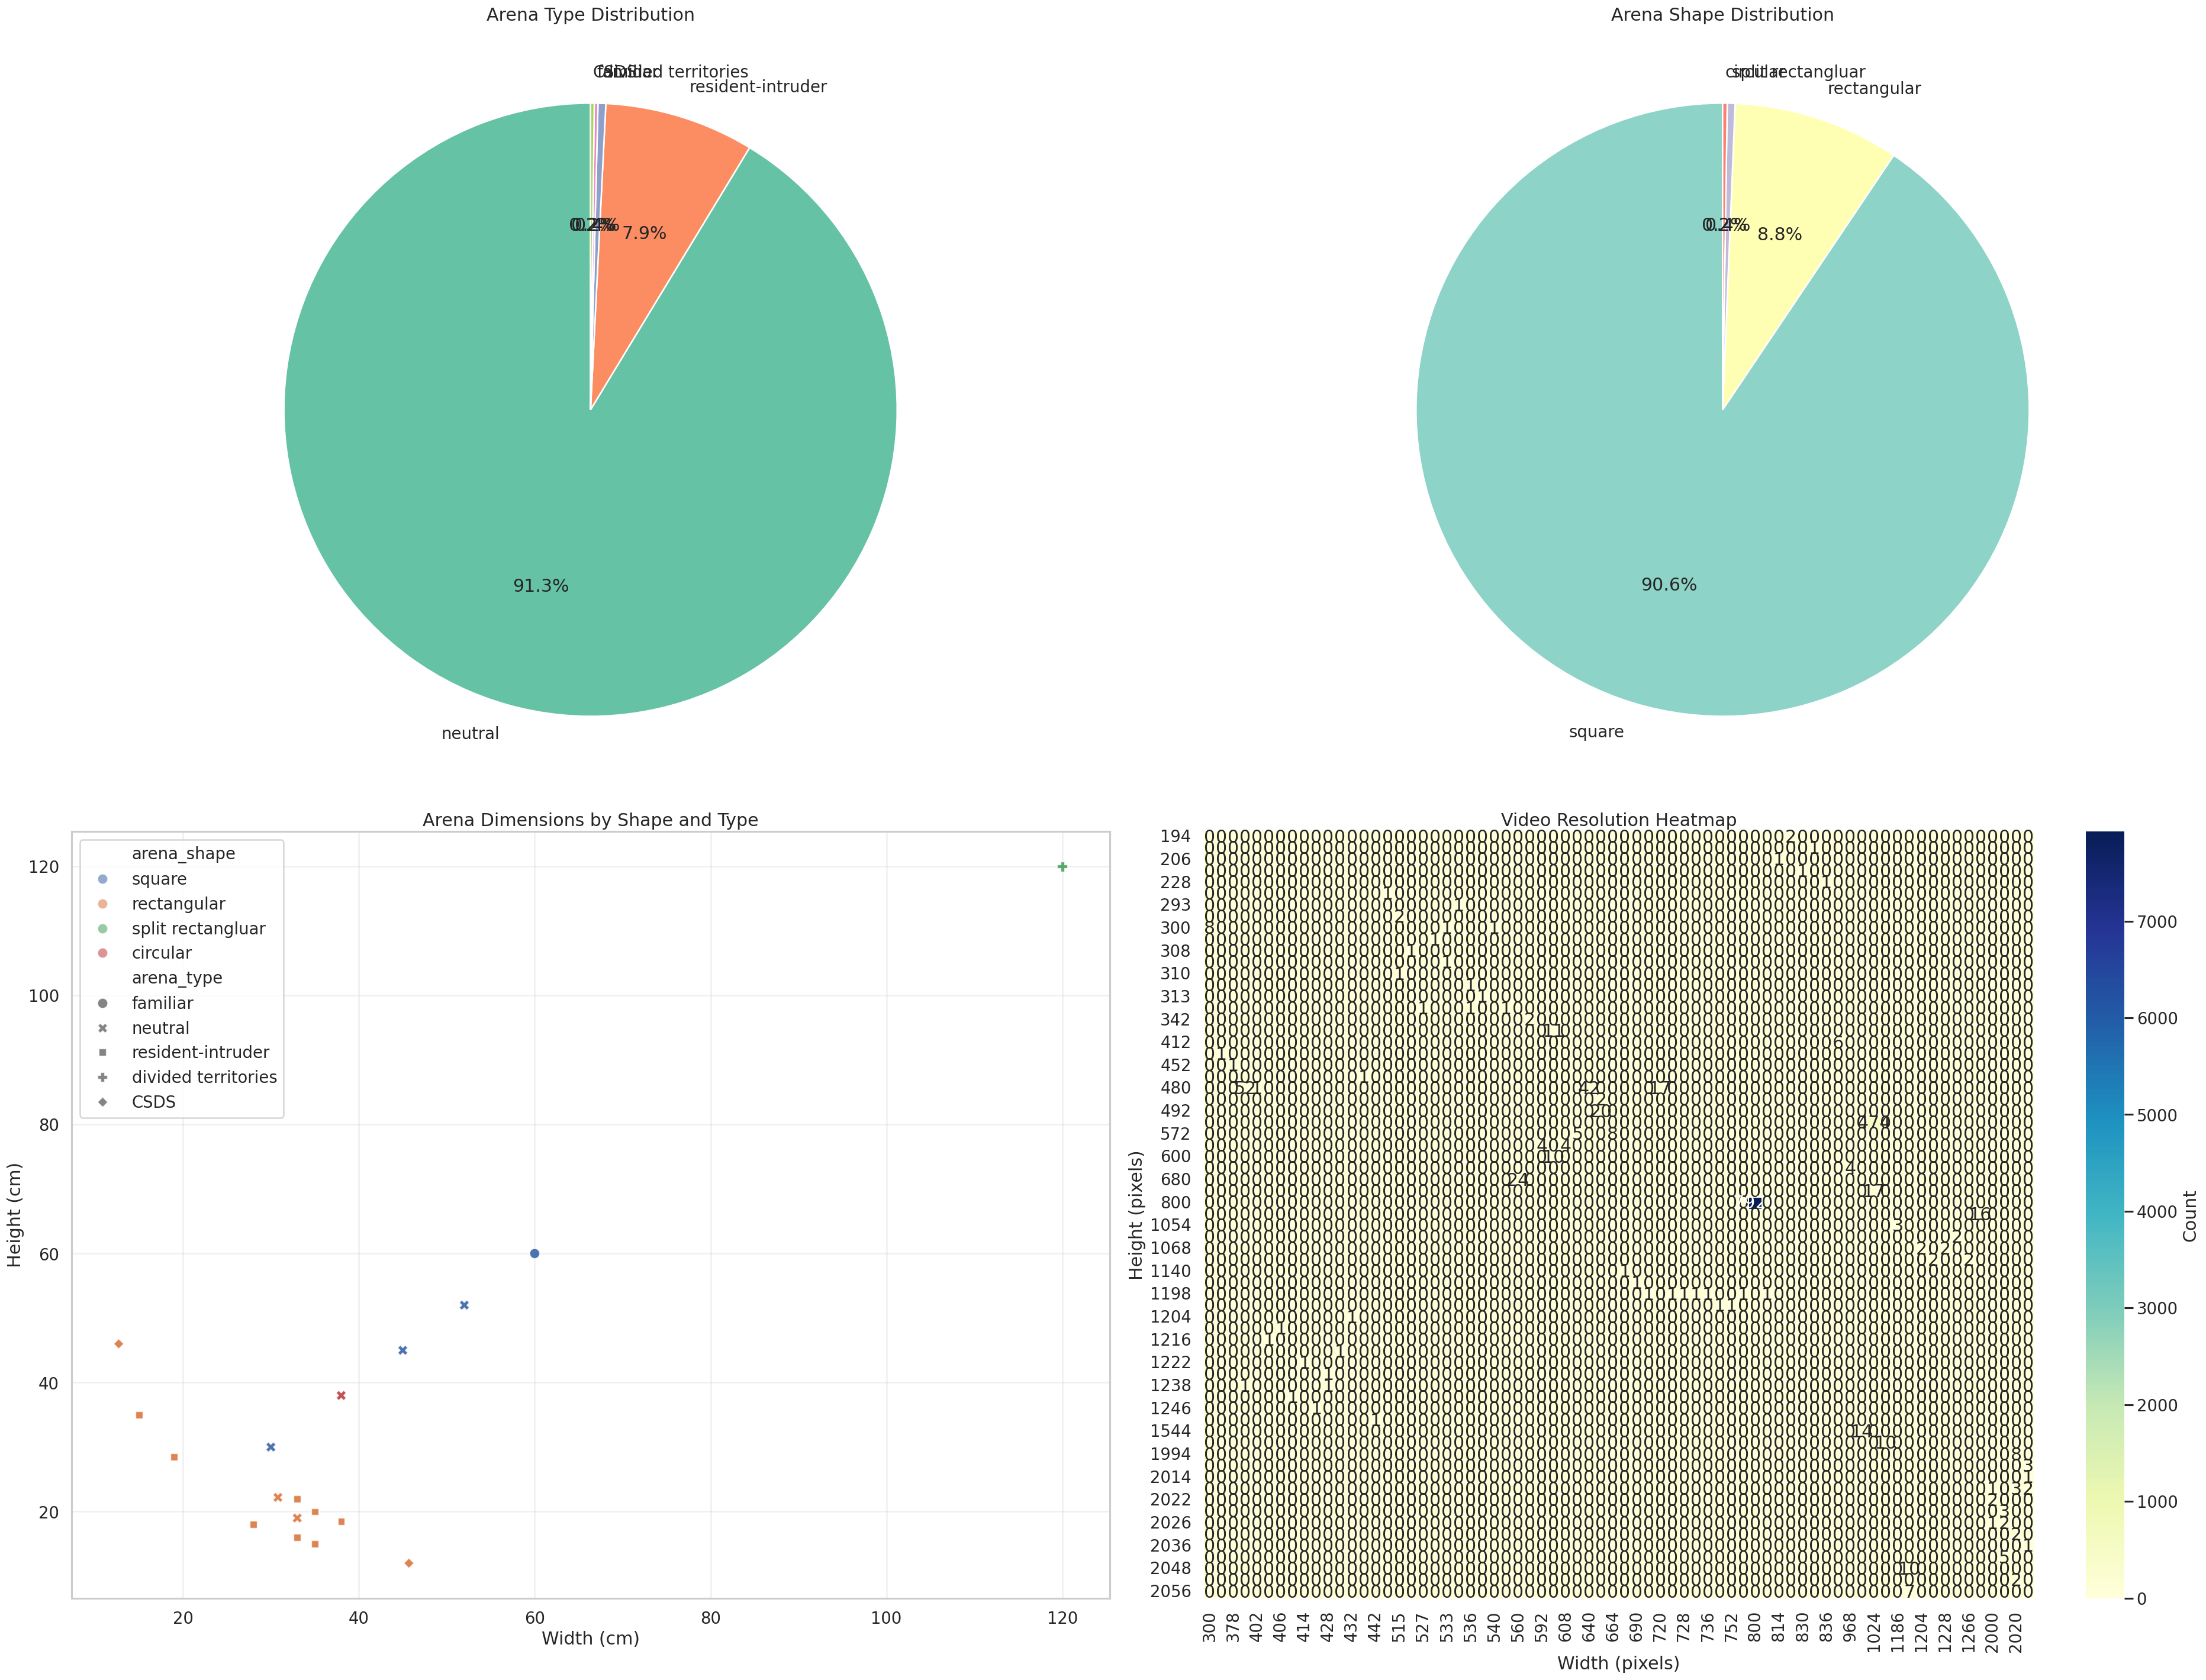

In [7]:
# Arena analysis with cross-tabulations
fig, axes = plt.subplots(2, 2, figsize=(32, 24))

# Arena type distribution with percentages
ax = axes[0, 0]
arena_type_counts = train['arena_type'].value_counts()
wedges, texts, autotexts = ax.pie(arena_type_counts.values, labels=arena_type_counts.index, 
                                    autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
ax.set_title('Arena Type Distribution')

# Arena shape distribution
ax = axes[0, 1]
arena_shape_counts = train['arena_shape'].value_counts()
wedges, texts, autotexts = ax.pie(arena_shape_counts.values, labels=arena_shape_counts.index, 
                                    autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set3'))
ax.set_title('Arena Shape Distribution')

# Arena dimensions scatter
ax = axes[1, 0]
sns.scatterplot(data=train, x='arena_width_cm', y='arena_height_cm', 
                hue='arena_shape', style='arena_type', s=100, alpha=0.6, ax=ax)
ax.set_title('Arena Dimensions by Shape and Type')
ax.set_xlabel('Width (cm)')
ax.set_ylabel('Height (cm)')
ax.grid(alpha=0.3)

# Video resolution heatmap
ax = axes[1, 1]
resolution_counts = train.groupby(['video_width_pix', 'video_height_pix']).size().reset_index(name='count')
resolution_pivot = resolution_counts.pivot(index='video_height_pix', columns='video_width_pix', values='count').fillna(0)
sns.heatmap(resolution_pivot, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Video Resolution Heatmap')
ax.set_xlabel('Width (pixels)')
ax.set_ylabel('Height (pixels)')

plt.tight_layout()
plt.savefig(figures_dir / "arena_configuration_analysis.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 6. Mouse Characteristics - Deep Dive

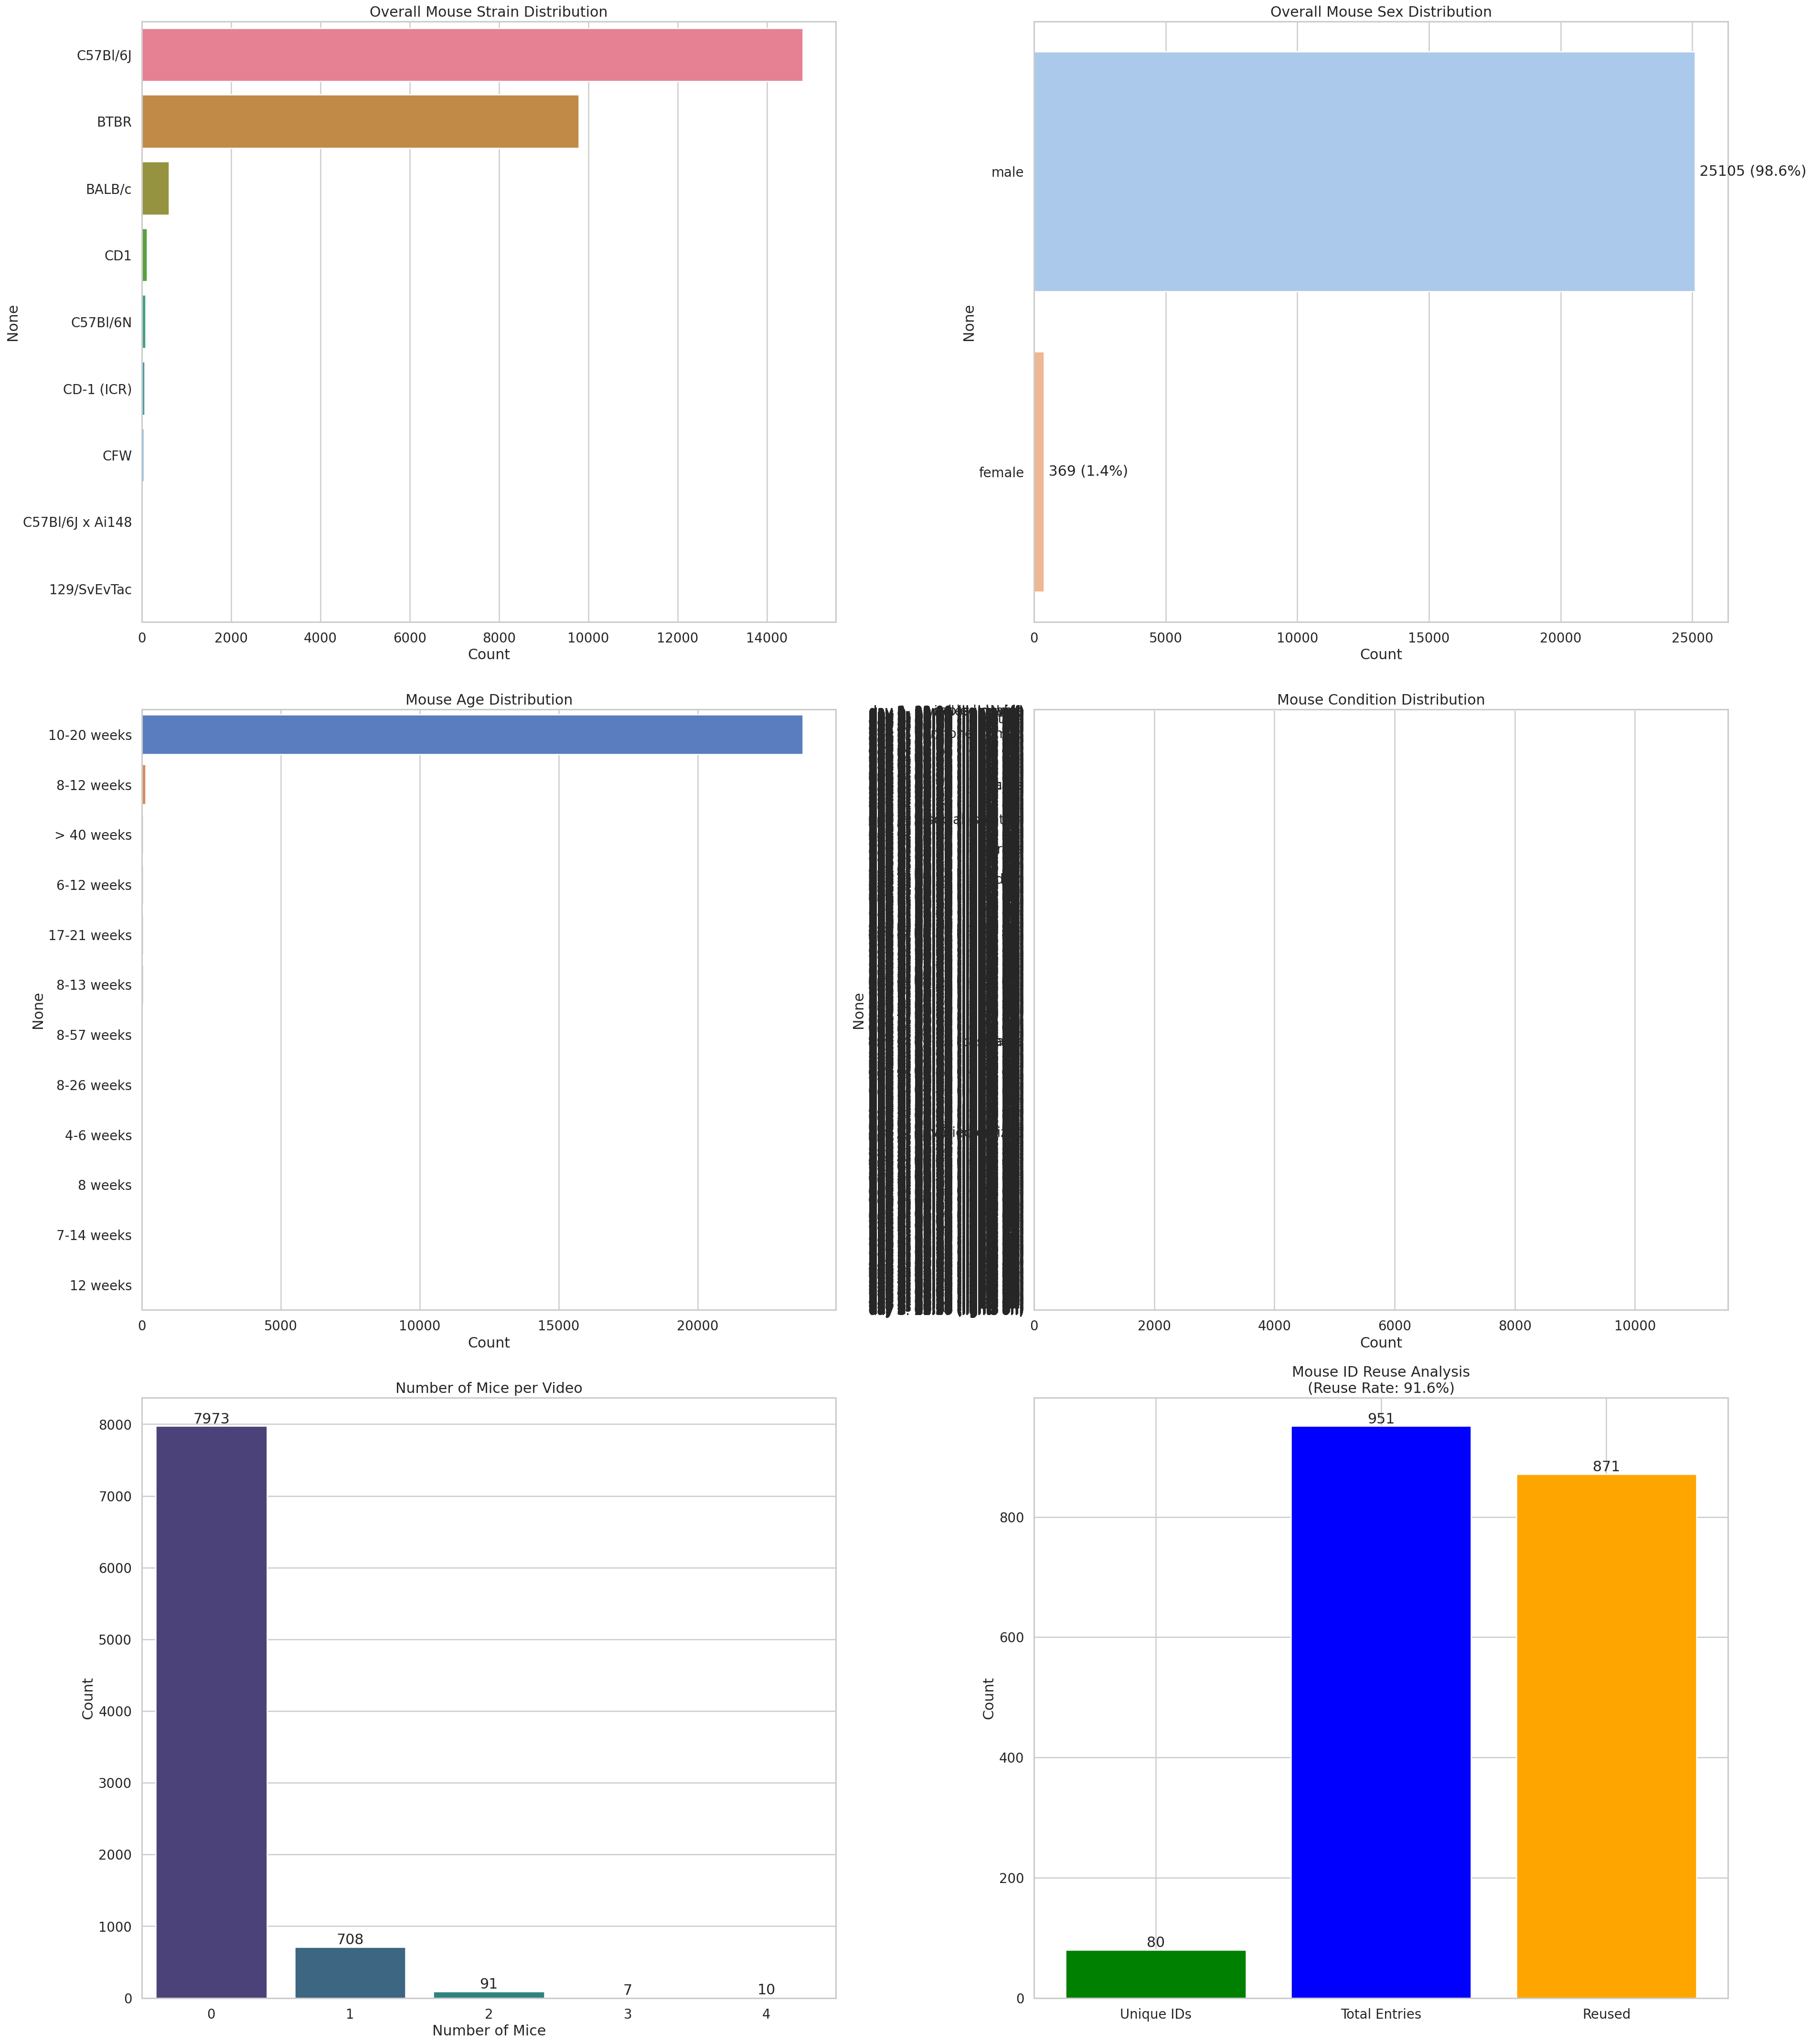

In [8]:
# Comprehensive mouse analysis
fig, axes = plt.subplots(3, 2, figsize=(32, 36))

# Mouse strain distribution across all mice
ax = axes[0, 0]
strain_data = []
for i in range(1, 5):
    col = f'mouse{i}_strain'
    if col in train.columns:
        strain_data.extend(train[col].dropna().tolist())
strain_series = pd.Series(strain_data)
strain_counts = strain_series.value_counts()
sns.barplot(x=strain_counts.values, y=strain_counts.index, ax=ax, palette='husl')
ax.set_title('Overall Mouse Strain Distribution')
ax.set_xlabel('Count')

# Sex distribution across all mice
ax = axes[0, 1]
sex_data = []
for i in range(1, 5):
    col = f'mouse{i}_sex'
    if col in train.columns:
        sex_data.extend(train[col].dropna().tolist())
sex_series = pd.Series(sex_data)
sex_counts = sex_series.value_counts()
sns.barplot(x=sex_counts.values, y=sex_counts.index, ax=ax, palette='pastel')
ax.set_title('Overall Mouse Sex Distribution')
ax.set_xlabel('Count')
for i, v in enumerate(sex_counts.values):
    ax.text(v, i, f' {v} ({v/sex_counts.sum()*100:.1f}%)', va='center')

# Age distribution
ax = axes[1, 0]
age_data = []
for i in range(1, 5):
    col = f'mouse{i}_age'
    if col in train.columns:
        age_data.extend(train[col].dropna().tolist())
age_series = pd.Series(age_data)
age_counts = age_series.value_counts()
sns.barplot(x=age_counts.values, y=age_counts.index, ax=ax, palette='muted')
ax.set_title('Mouse Age Distribution')
ax.set_xlabel('Count')

# Condition distribution (wireless device vs NaN)
ax = axes[1, 1]
condition_data = []
for i in range(1, 5):
    col = f'mouse{i}_condition'
    if col in train.columns:
        condition_data.extend(train[col].fillna('None').tolist())
condition_series = pd.Series(condition_data)
condition_counts = condition_series.value_counts()
sns.barplot(x=condition_counts.values, y=condition_counts.index, ax=ax, palette='Set1')
ax.set_title('Mouse Condition Distribution')
ax.set_xlabel('Count')

# Mouse presence across experiments (how many mice per video)
ax = axes[2, 0]
mouse_cols = [f'mouse{i}_id' for i in range(1, 5)]
mice_per_video = train[mouse_cols].notna().sum(axis=1)
mice_counts = mice_per_video.value_counts().sort_index()
sns.barplot(x=mice_counts.index, y=mice_counts.values, ax=ax, palette='viridis')
ax.set_title('Number of Mice per Video')
ax.set_xlabel('Number of Mice')
ax.set_ylabel('Count')
for i, v in enumerate(mice_counts.values):
    ax.text(i, v, f'{v}', ha='center', va='bottom')

# Mouse ID distribution (to check for reuse)
ax = axes[2, 1]
id_data = []
for i in range(1, 5):
    col = f'mouse{i}_id'
    if col in train.columns:
        id_data.extend(train[col].dropna().tolist())
unique_ids = len(set(id_data))
total_ids = len(id_data)
reuse_rate = (total_ids - unique_ids) / total_ids * 100

ax.bar(['Unique IDs', 'Total Entries', 'Reused'], 
       [unique_ids, total_ids, total_ids - unique_ids], 
       color=['green', 'blue', 'orange'])
ax.set_title(f'Mouse ID Reuse Analysis\n(Reuse Rate: {reuse_rate:.1f}%)')
ax.set_ylabel('Count')
for i, v in enumerate([unique_ids, total_ids, total_ids - unique_ids]):
    ax.text(i, v, f'{v}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(figures_dir / "mouse_characteristics_comprehensive.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 7. Correlation and Relationships


HIGH CORRELATION PAIRS


,Feature 1,Feature 2,Correlation
1,mouse1_id,mouse3_id,1.000000
3,mouse2_id,mouse3_id,1.000000
4,mouse2_id,mouse4_id,0.995015
5,mouse3_id,mouse4_id,0.995015
2,mouse1_id,mouse4_id,0.995015
16,arena_width_cm,arena_height_cm,0.879768
9,mouse4_id,pix_per_cm_approx,0.845657
7,mouse4_id,frames_per_second,0.845657
8,mouse4_id,video_duration_sec,-0.845647
11,mouse4_id,video_height_pix,0.815665


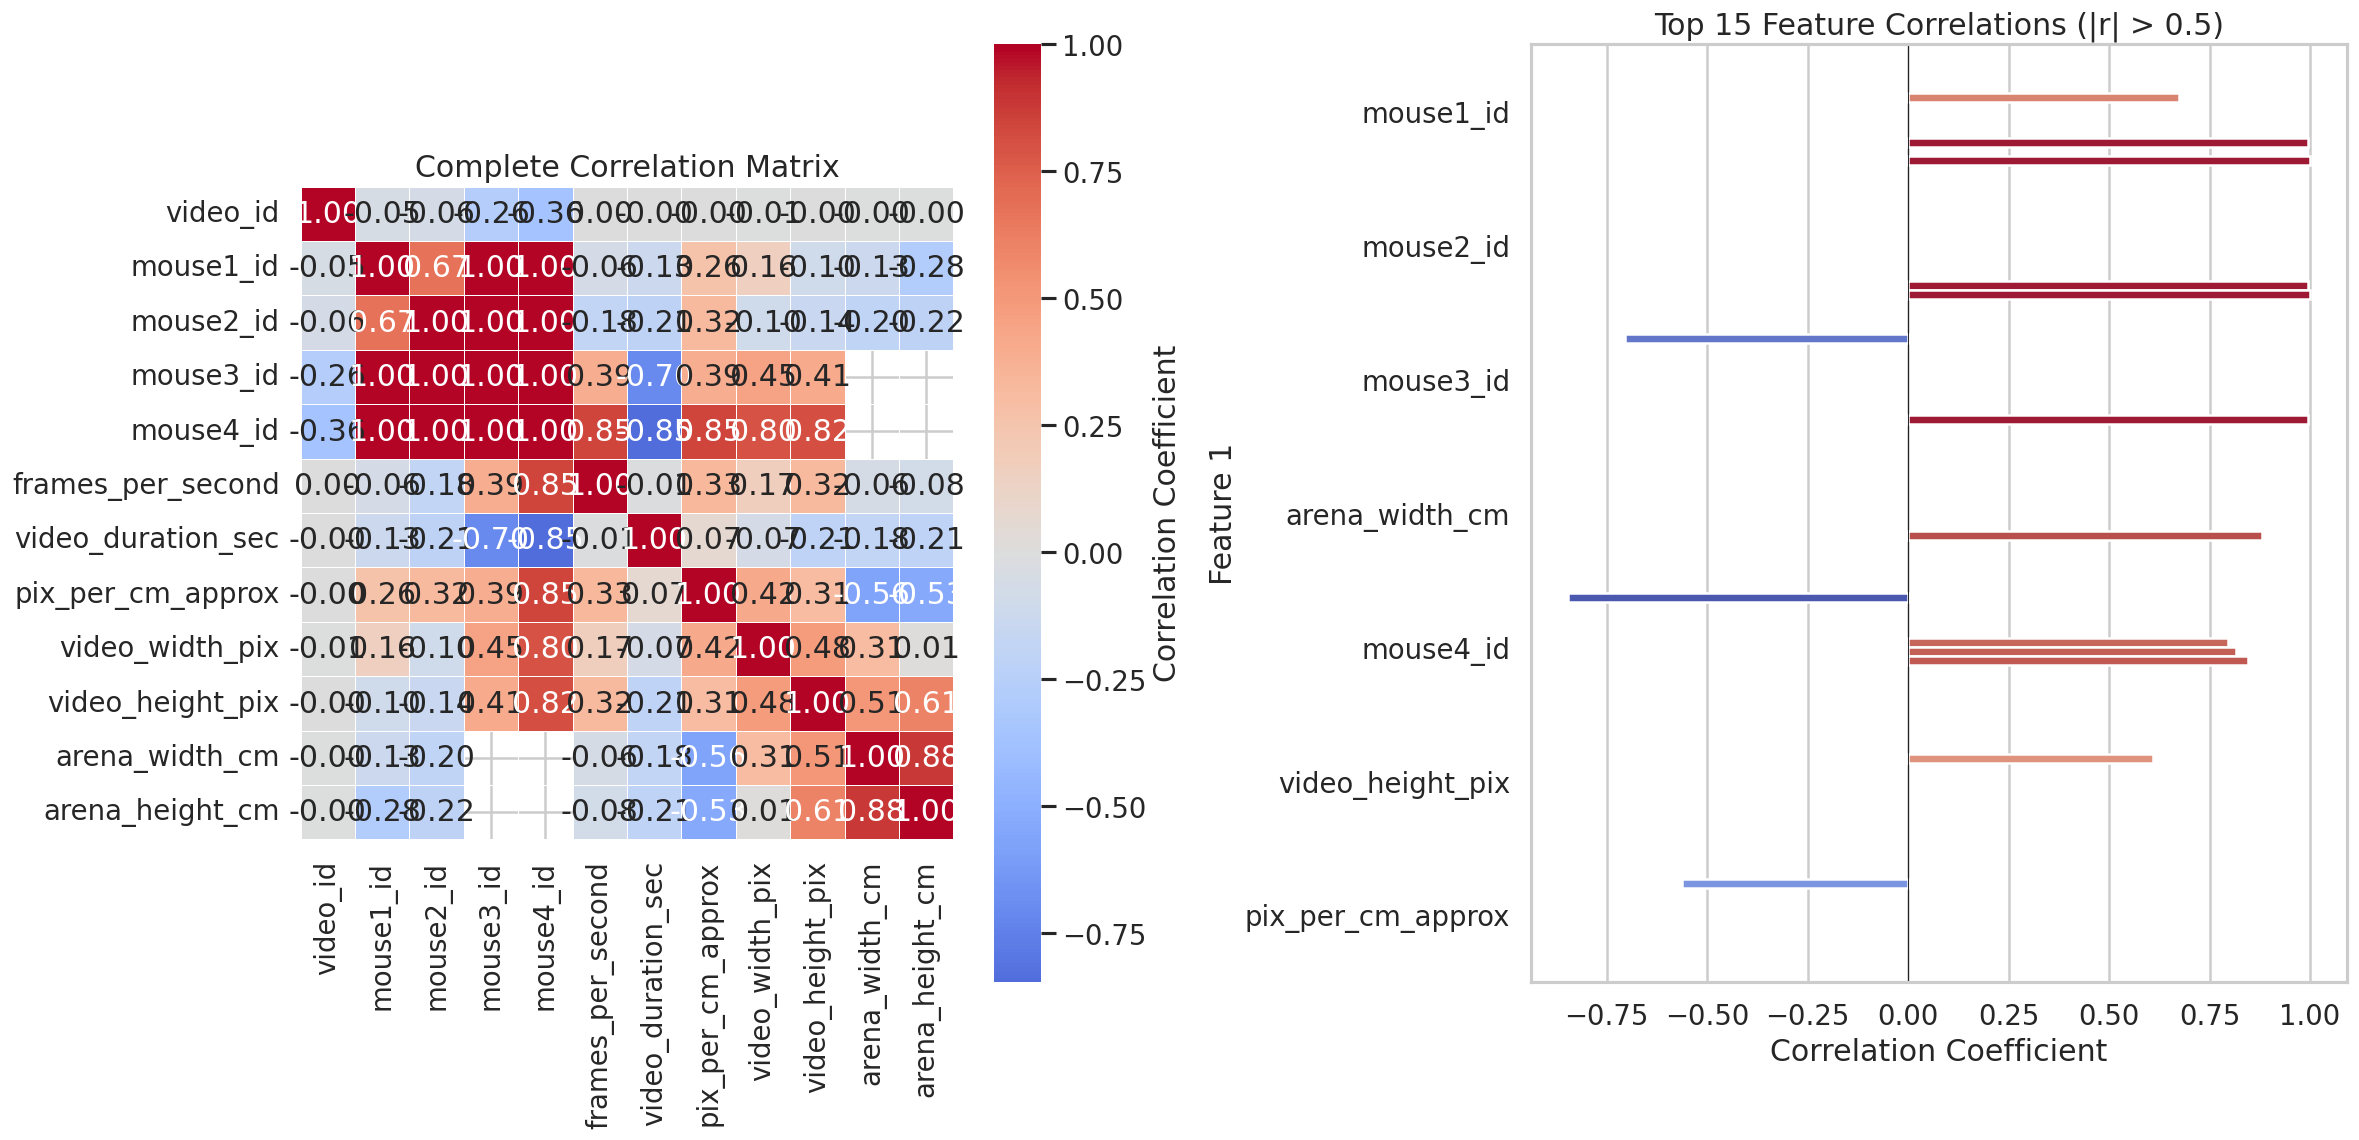

In [9]:
# Advanced correlation analysis
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = train[numeric_cols].corr()

# Full correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

ax = axes[0]
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Complete Correlation Matrix')

# High correlation pairs only
ax = axes[1]
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    sns.barplot(data=high_corr_df.head(15), y='Feature 1', x='Correlation', 
                ax=ax, palette='coolwarm', hue='Correlation', legend=False)
    ax.set_title('Top 15 Feature Correlations (|r| > 0.5)')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Correlation Coefficient')

    print("\n" + "=" * 80)
    print("HIGH CORRELATION PAIRS")
    print("=" * 80)
    display(high_corr_df)

plt.tight_layout()
plt.savefig(figures_dir / "correlation_advanced_analysis.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 8. Sample Tracking Data - Deep Analysis

In [10]:
print("\n" + "=" * 80)
print("LOADING SAMPLE TRACKING DATA")
print("=" * 80)

# Load multiple tracking files for robust analysis
tracking_files = list((base_path / "train_tracking").rglob("*.parquet"))[:5]  # First 5 files
tracking_dfs = []

for file in tracking_files:
    df = pd.read_parquet(file)
    df['source_file'] = file.stem
    tracking_dfs.append(df)
    print(f"Loaded: {file.name} - {df.shape[0]:,} rows")

tracking_combined = pd.concat(tracking_dfs, ignore_index=True)
print(f"\nCombined tracking data: {tracking_combined.shape}")


LOADING SAMPLE TRACKING DATA
Loaded: 1715161851.parquet - 140,196 rows
Loaded: 427469519.parquet - 20,958 rows
Loaded: 13638642.parquet - 88,620 rows
Loaded: 662173177.parquet - 272,622 rows
Loaded: 877503292.parquet - 145,460 rows

Combined tracking data: (667856, 6)


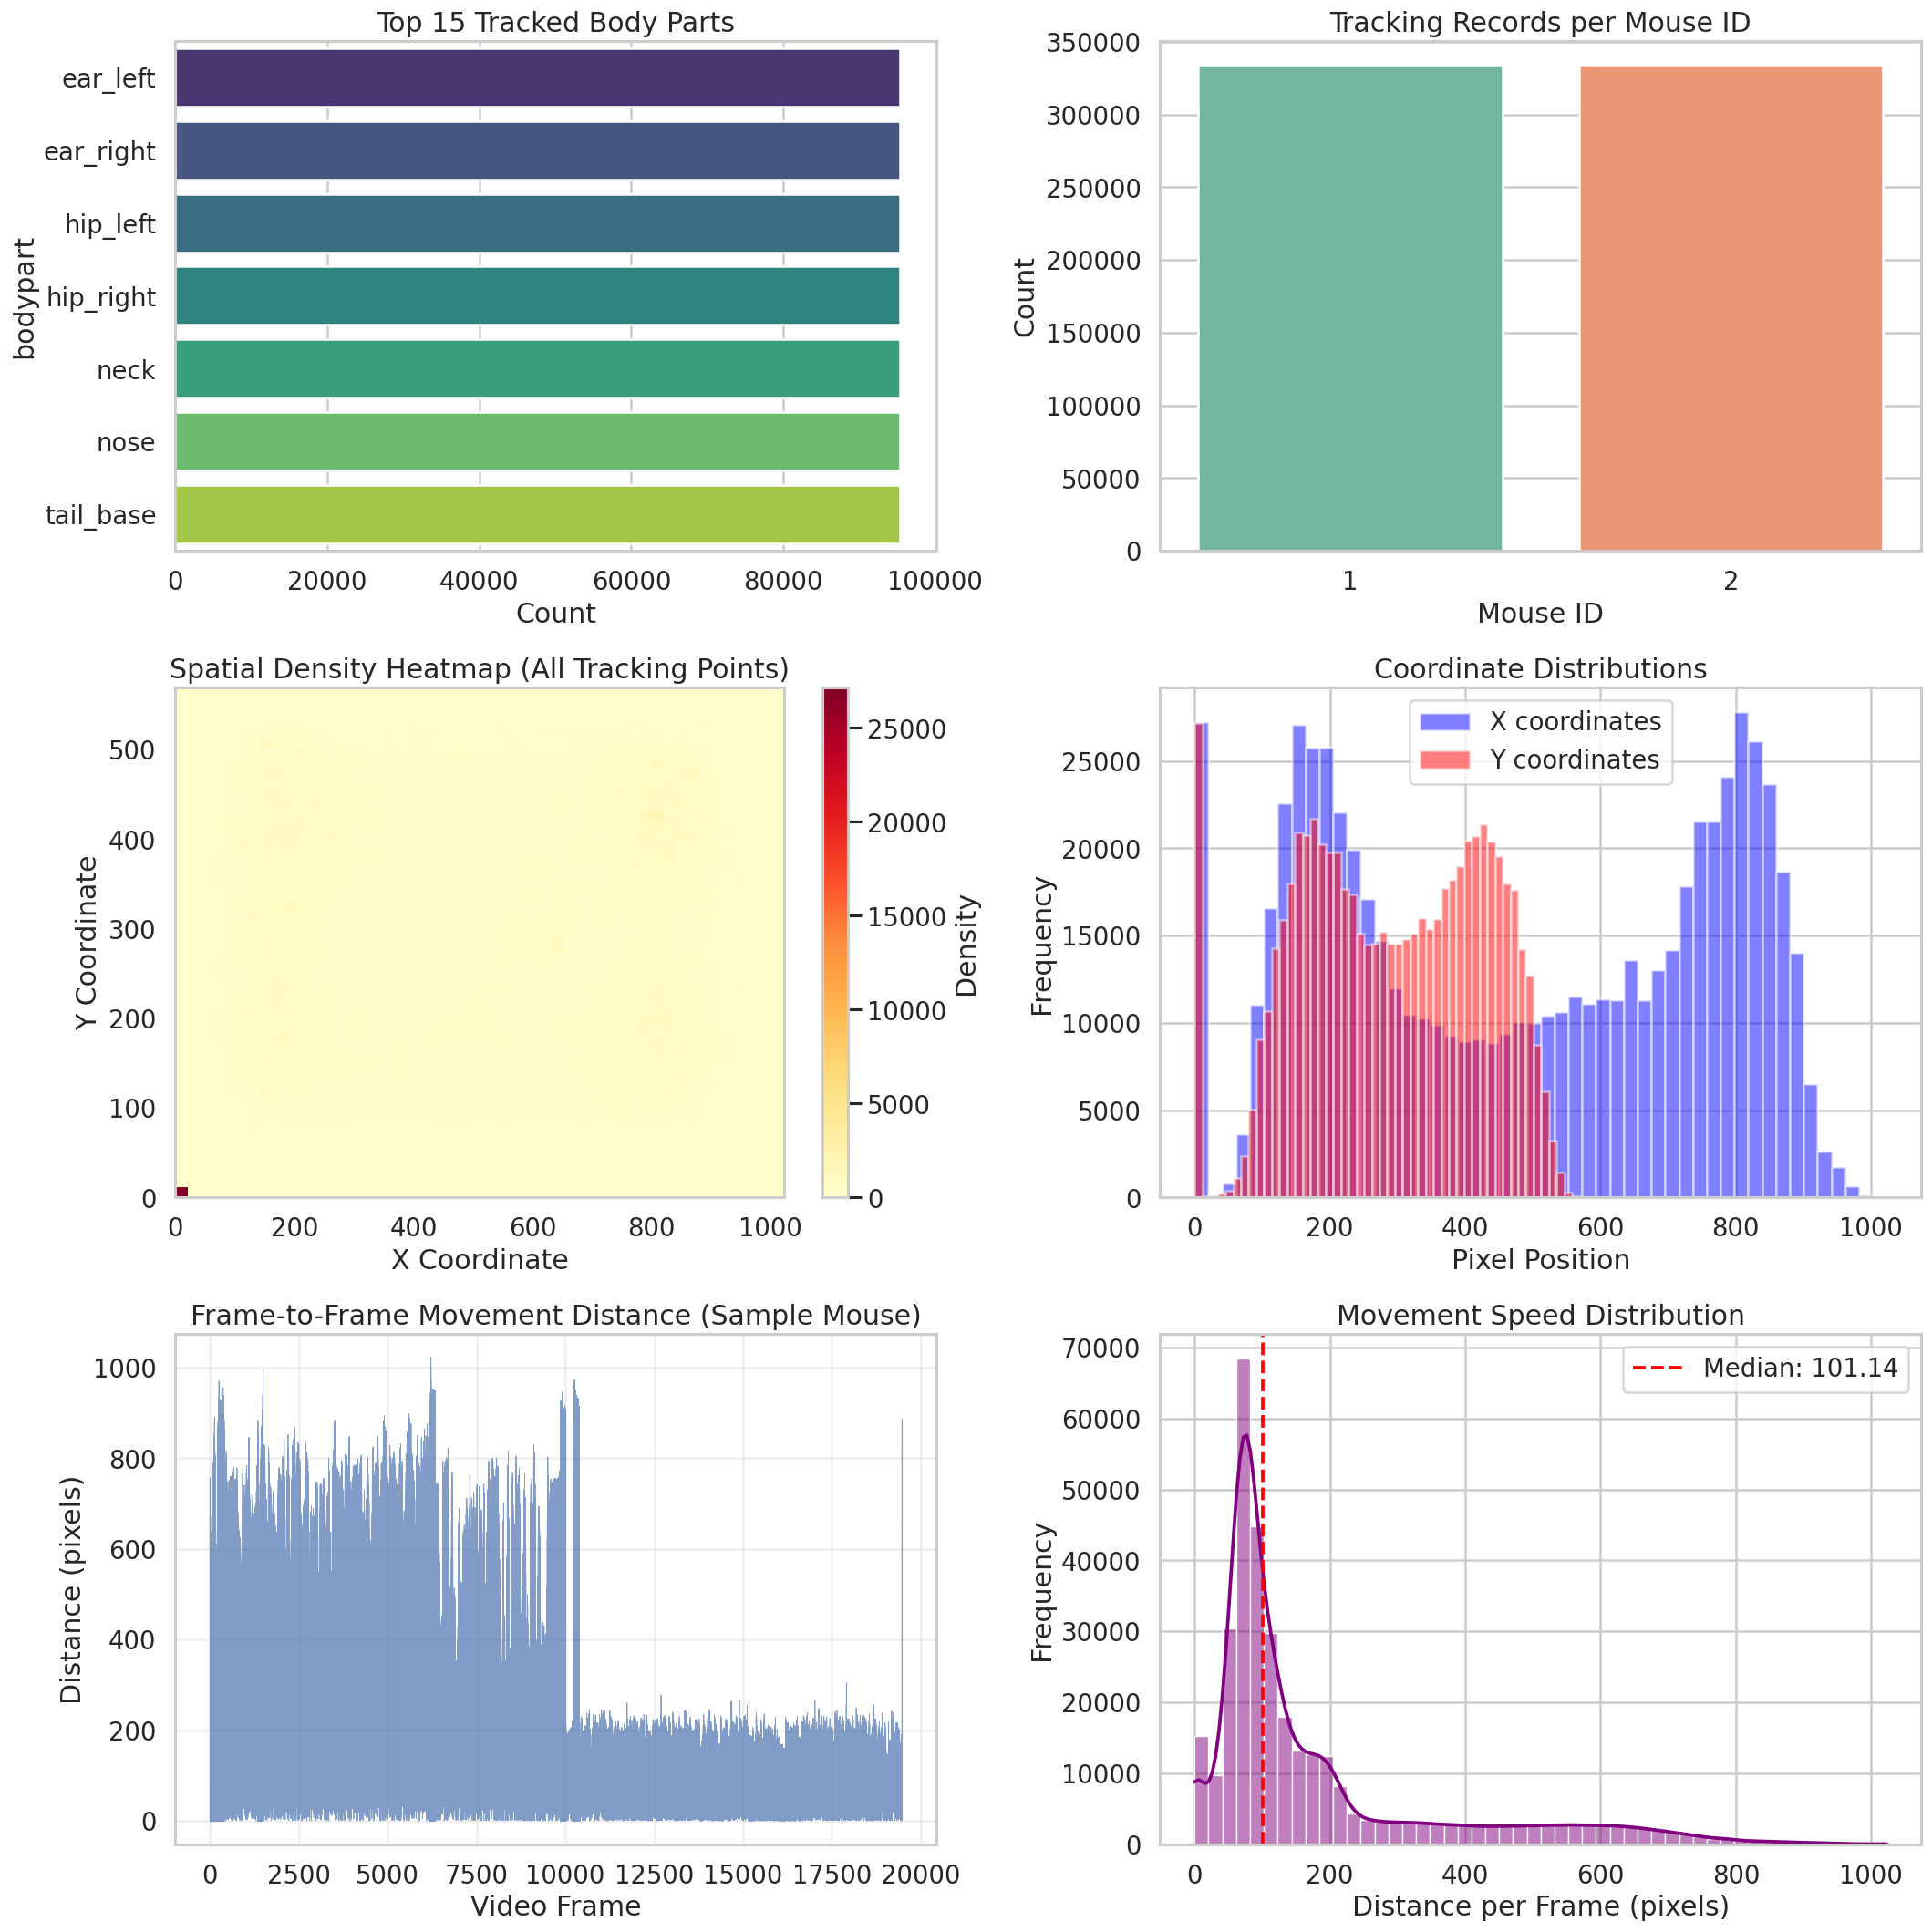

In [11]:
# Tracking data comprehensive analysis
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# Body part frequency
ax = axes[0, 0]
bodypart_counts = tracking_combined['bodypart'].value_counts().head(15)
sns.barplot(x=bodypart_counts.values, y=bodypart_counts.index, ax=ax, palette='viridis')
ax.set_title('Top 15 Tracked Body Parts')
ax.set_xlabel('Count')

# Mouse ID distribution in tracking
ax = axes[0, 1]
mouse_id_counts = tracking_combined['mouse_id'].value_counts()
sns.barplot(x=mouse_id_counts.index, y=mouse_id_counts.values, ax=ax, palette='Set2')
ax.set_title('Tracking Records per Mouse ID')
ax.set_xlabel('Mouse ID')
ax.set_ylabel('Count')

# Spatial distribution - 2D histogram
ax = axes[1, 0]
h = ax.hist2d(tracking_combined['x'], tracking_combined['y'], bins=50, cmap='YlOrRd')
ax.set_title('Spatial Density Heatmap (All Tracking Points)')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
plt.colorbar(h[3], ax=ax, label='Density')

# Coordinate distributions
ax = axes[1, 1]
ax.hist(tracking_combined['x'], bins=50, alpha=0.5, label='X coordinates', color='blue')
ax.hist(tracking_combined['y'], bins=50, alpha=0.5, label='Y coordinates', color='red')
ax.set_title('Coordinate Distributions')
ax.set_xlabel('Pixel Position')
ax.set_ylabel('Frequency')
ax.legend()

# Movement speed estimation (frame-to-frame distance)
sample_mouse = tracking_combined[tracking_combined['mouse_id'] == tracking_combined['mouse_id'].mode()[0]]
sample_mouse = sample_mouse.sort_values('video_frame')
sample_mouse['dx'] = sample_mouse['x'].diff()
sample_mouse['dy'] = sample_mouse['y'].diff()
sample_mouse['distance'] = np.sqrt(sample_mouse['dx']**2 + sample_mouse['dy']**2)

ax = axes[2, 0]
ax.plot(sample_mouse['video_frame'], sample_mouse['distance'], alpha=0.7, linewidth=0.5)
ax.set_title('Frame-to-Frame Movement Distance (Sample Mouse)')
ax.set_xlabel('Video Frame')
ax.set_ylabel('Distance (pixels)')
ax.grid(alpha=0.3)

# Movement speed distribution
ax = axes[2, 1]
sns.histplot(sample_mouse['distance'].dropna(), bins=50, kde=True, ax=ax, color='purple')
ax.set_title('Movement Speed Distribution')
ax.set_xlabel('Distance per Frame (pixels)')
ax.set_ylabel('Frequency')
ax.axvline(sample_mouse['distance'].median(), color='red', linestyle='--', 
           label=f"Median: {sample_mouse['distance'].median():.2f}")
ax.legend()

plt.tight_layout()
plt.savefig(figures_dir / "tracking_data_comprehensive.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 9. Sample Annotation Data Analysis

In [12]:
print("\n" + "=" * 80)
print("LOADING SAMPLE ANNOTATION DATA")
print("=" * 80)

# Load annotation files
annotation_files = list((base_path / "train_annotation").rglob("*.parquet"))[:5]
annotation_dfs = []

for file in annotation_files:
    df = pd.read_parquet(file)
    df['source_file'] = file.stem
    annotation_dfs.append(df)
    print(f"Loaded: {file.name} - {df.shape[0]:,} rows")

annotation_combined = pd.concat(annotation_dfs, ignore_index=True)
print(f"\nCombined annotation data: {annotation_combined.shape}")


LOADING SAMPLE ANNOTATION DATA
Loaded: 1715161851.parquet - 48 rows
Loaded: 427469519.parquet - 25 rows
Loaded: 13638642.parquet - 65 rows
Loaded: 662173177.parquet - 276 rows
Loaded: 877503292.parquet - 57 rows

Combined annotation data: (471, 6)


In [13]:
# Annotation analysis
if 'behavior' in annotation_combined.columns:
    fig, axes = plt.subplots(2, 2, figsize=(36, 24))

    # Behavior frequency
    ax = axes[0, 0]
    behavior_counts = annotation_combined['behavior'].value_counts().head(20)
    sns.barplot(x=behavior_counts.values, y=behavior_counts.index, ax=ax, palette='rocket')
    ax.set_title('Top 20 Annotated Behaviors')
    ax.set_xlabel('Frequency')

    # Annotation duration analysis
    if 'start' in annotation_combined.columns and 'end' in annotation_combined.columns:
        annotation_combined['duration'] = annotation_combined['end'] - annotation_combined['start']

        ax = axes[0, 1]
        sns.histplot(annotation_combined['duration'], bins=50, kde=True, ax=ax, color='teal')
        ax.set_title('Behavior Duration Distribution')
        ax.set_xlabel('Duration (frames)')
        ax.set_ylabel('Frequency')

        # Duration by behavior type
        ax = axes[1, 0]
        top_behaviors = behavior_counts.head(10).index
        duration_by_behavior = annotation_combined[annotation_combined['behavior'].isin(top_behaviors)]
        sns.boxplot(data=duration_by_behavior, y='behavior', x='duration', ax=ax, palette='Set3')
        ax.set_title('Duration Distribution by Top 10 Behaviors')
        ax.set_xlabel('Duration (frames)')

    # Behavior co-occurrence (if multiple mice involved)
    ax = axes[1, 1]
    # Extract interaction types from behavior strings
    behaviors = annotation_combined['behavior'].str.split(',', expand=True)
    if behaviors.shape[1] >= 3:
        interaction_types = behaviors[2].value_counts().head(10)
        sns.barplot(x=interaction_types.values, y=interaction_types.index, ax=ax, palette='mako')
        ax.set_title('Top 10 Interaction Types')
        ax.set_xlabel('Count')

    plt.tight_layout()
    plt.savefig(figures_dir / "annotation_comprehensive_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

## 10. Temporal Patterns Analysis

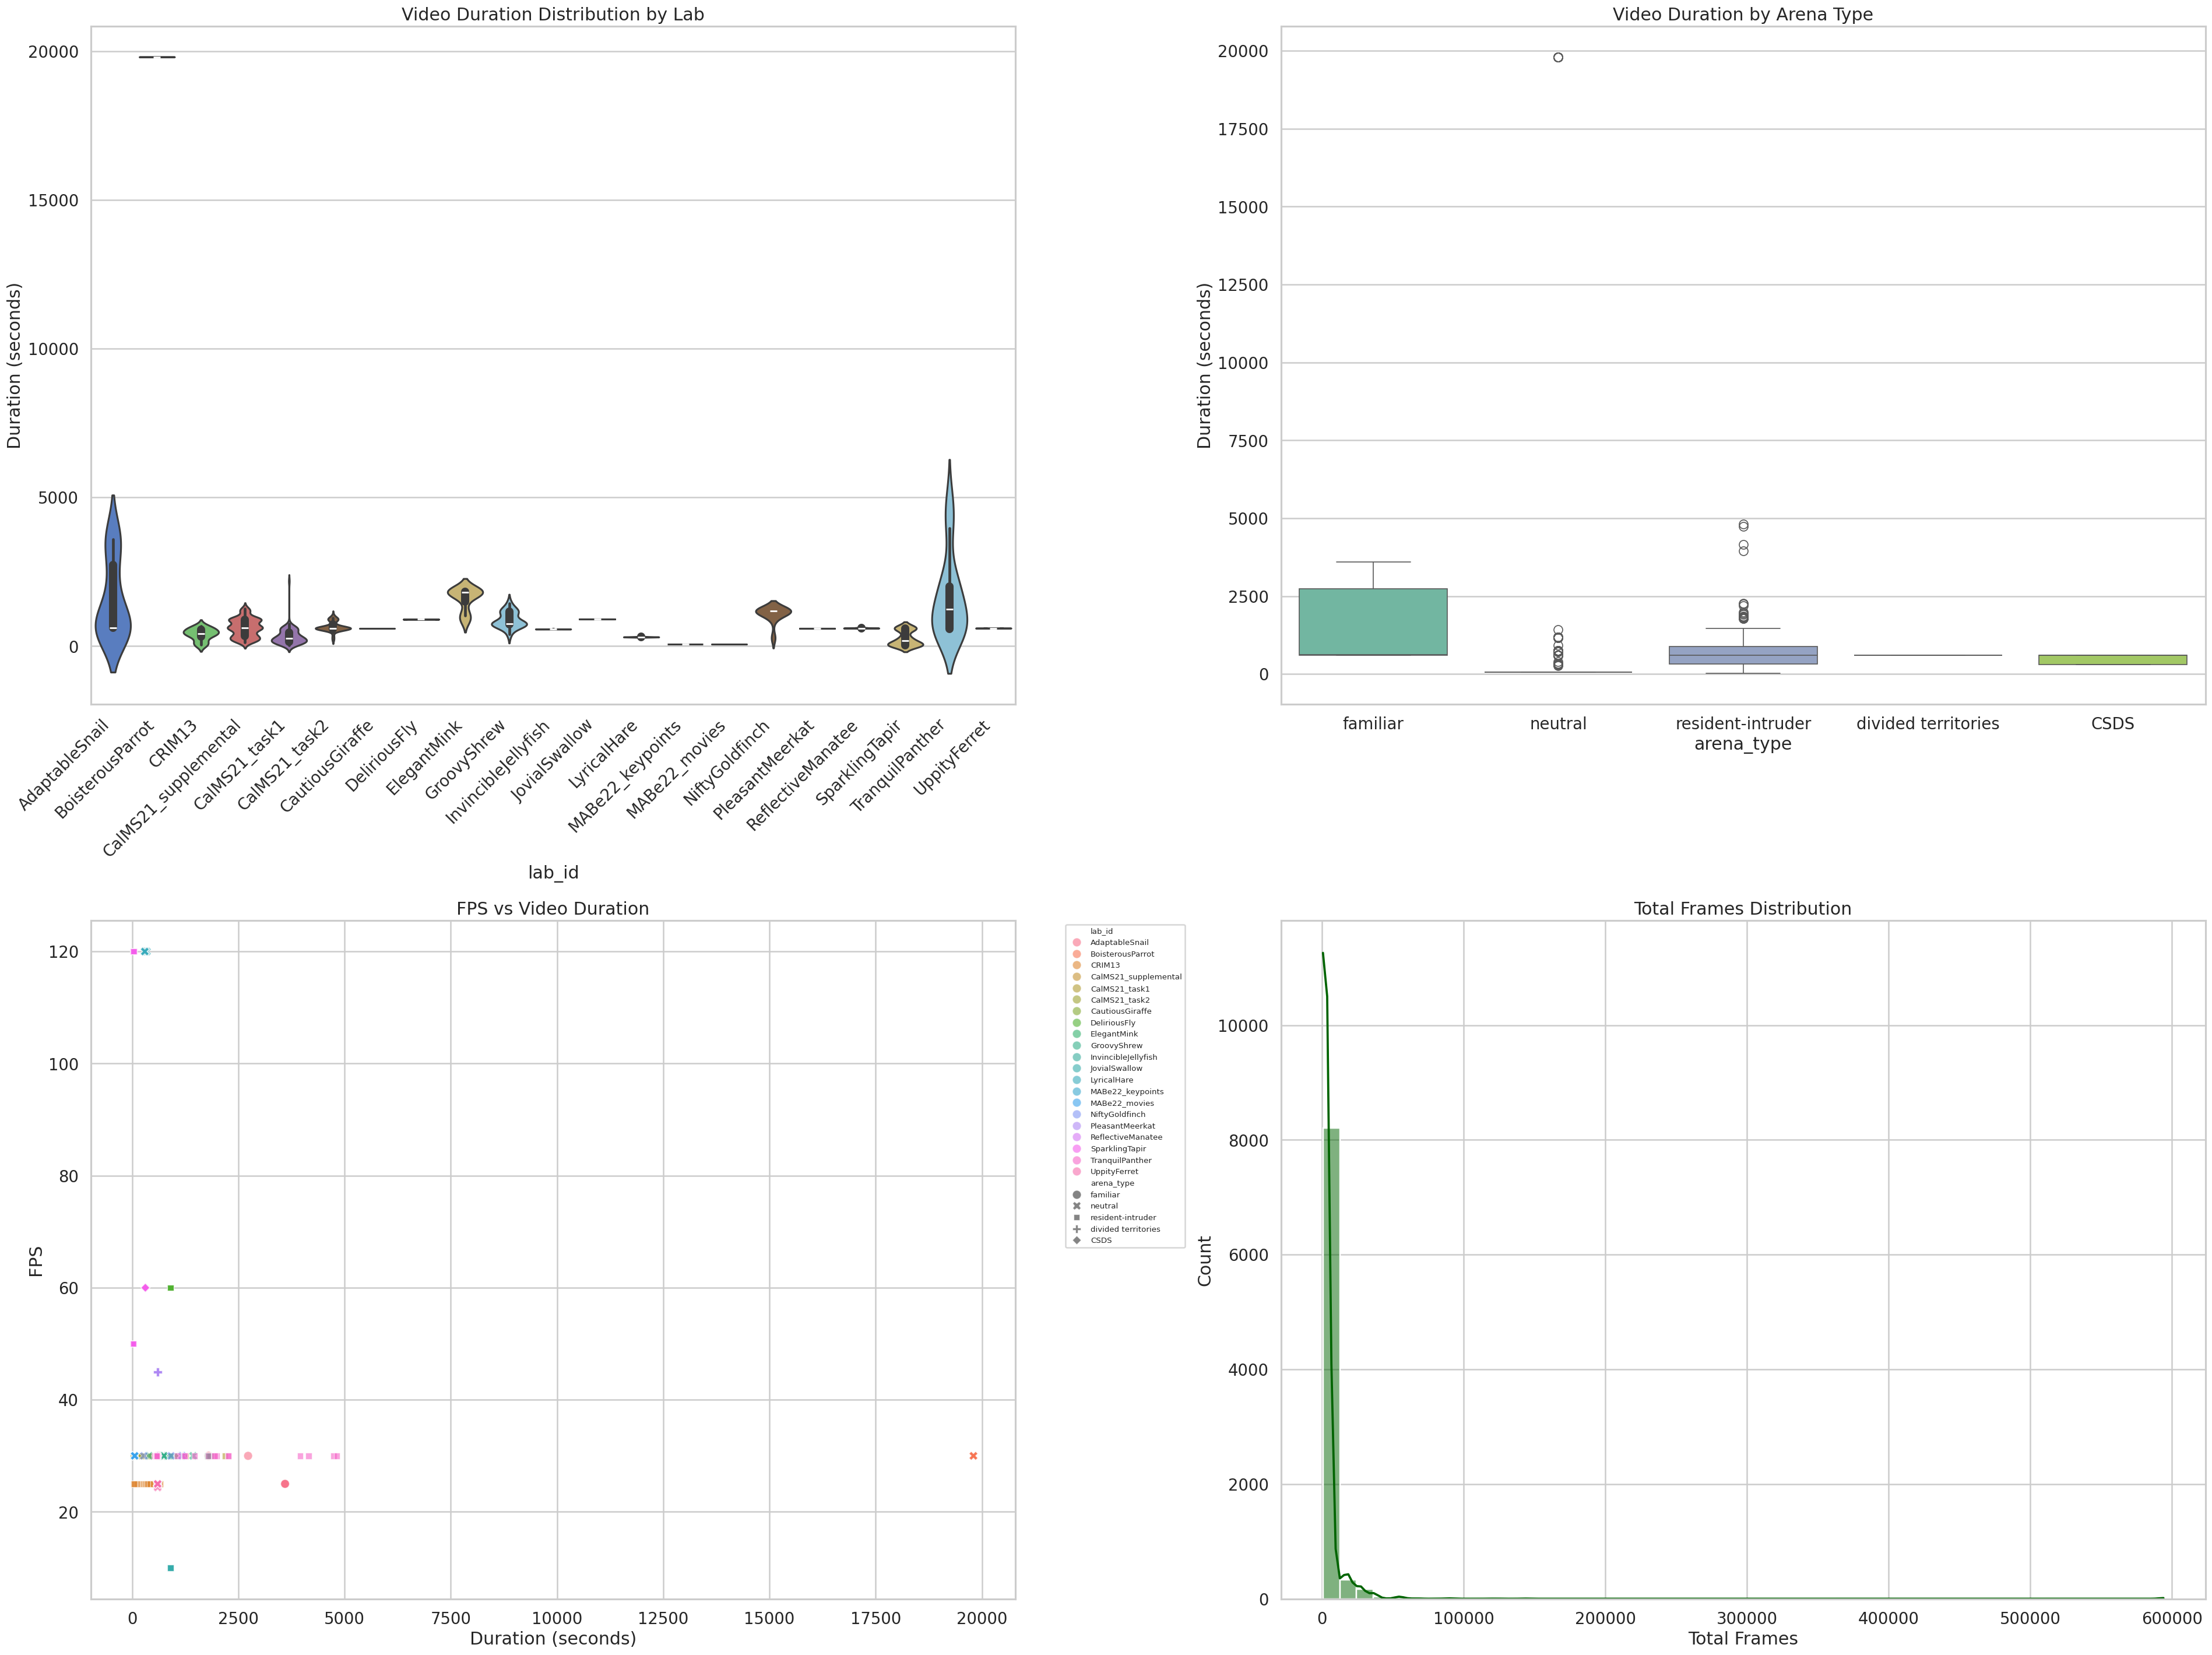

In [14]:
# Video duration patterns
fig, axes = plt.subplots(2, 2, figsize=(32, 24))

# Duration by lab
ax = axes[0, 0]
sns.violinplot(data=train, x='lab_id', y='video_duration_sec', ax=ax, palette='muted')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Video Duration Distribution by Lab')
ax.set_ylabel('Duration (seconds)')

# Duration by arena type
ax = axes[0, 1]
sns.boxplot(data=train, x='arena_type', y='video_duration_sec', ax=ax, palette='Set2')
ax.set_title('Video Duration by Arena Type')
ax.set_ylabel('Duration (seconds)')

# FPS vs Duration scatter
ax = axes[1, 0]
sns.scatterplot(data=train, x='video_duration_sec', y='frames_per_second', 
                hue='lab_id', style='arena_type', s=80, alpha=0.6, ax=ax)
ax.set_title('FPS vs Video Duration')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('FPS')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Total frames distribution
train['total_frames'] = train['video_duration_sec'] * train['frames_per_second']
ax = axes[1, 1]
sns.histplot(train['total_frames'], bins=50, kde=True, ax=ax, color='darkgreen')
ax.set_title('Total Frames Distribution')
ax.set_xlabel('Total Frames')
ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(figures_dir / "temporal_patterns_analysis.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 11. PCA and Dimensionality Reduction

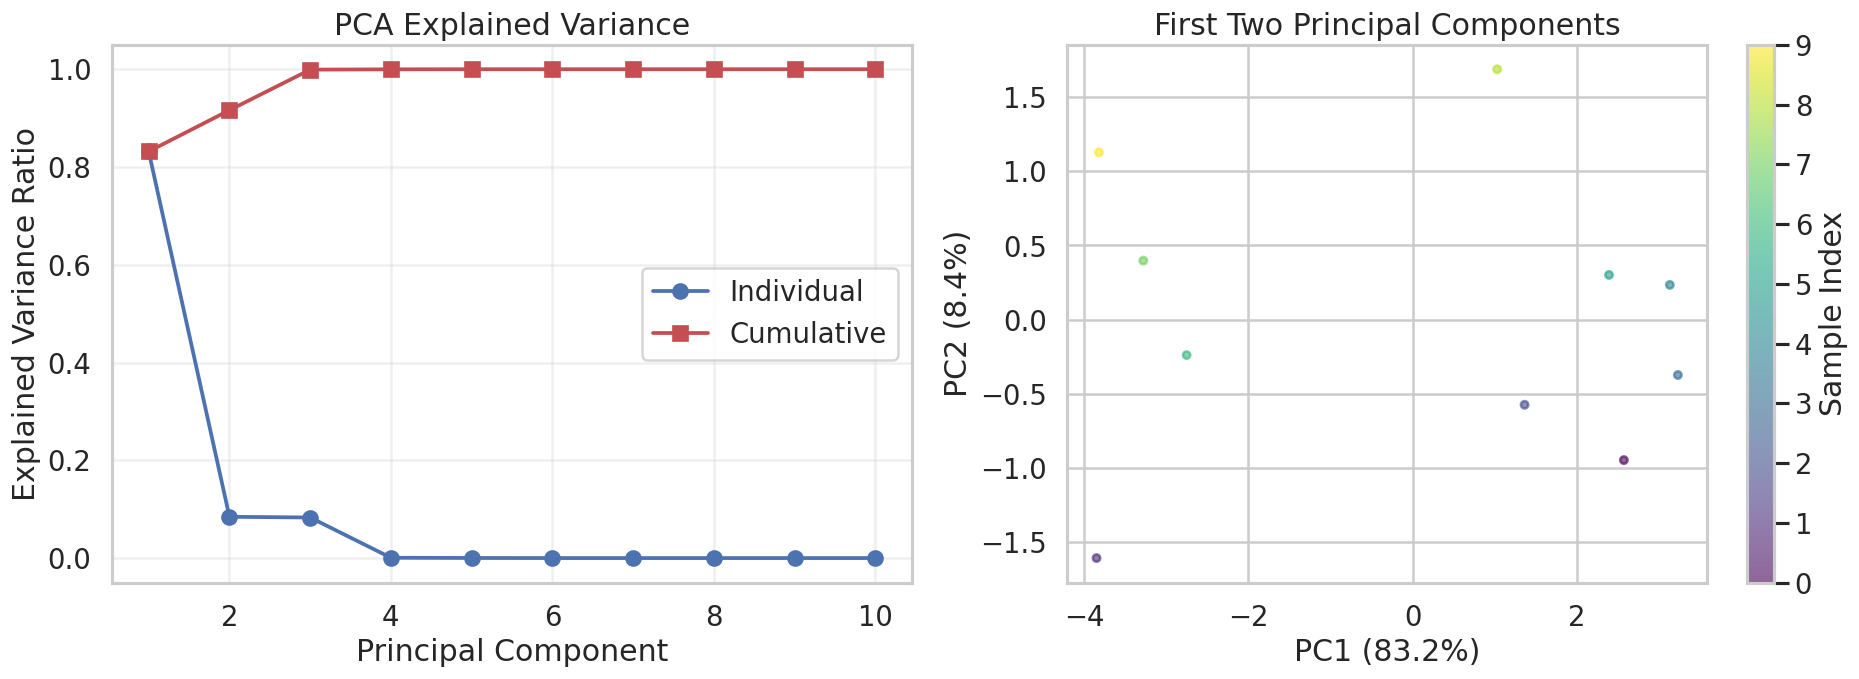


PCA SUMMARY
Number of components for 95% variance: 3
Number of components for 99% variance: 3


In [15]:
# PCA on numeric features
numeric_data = train[numeric_cols].dropna()

if len(numeric_data) > 0:
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(numeric_data)

    pca = PCA()
    pca_transformed = pca.fit_transform(scaled_data)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Explained variance
    ax = axes[0]
    explained_var = pca.explained_variance_ratio_
    cumsum_var = np.cumsum(explained_var)
    ax.plot(range(1, len(explained_var)+1), explained_var, 'bo-', label='Individual')
    ax.plot(range(1, len(explained_var)+1), cumsum_var, 'rs-', label='Cumulative')
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Explained Variance Ratio')
    ax.set_title('PCA Explained Variance')
    ax.legend()
    ax.grid(alpha=0.3)

    # PC1 vs PC2 scatter
    ax = axes[1]
    scatter = ax.scatter(pca_transformed[:, 0], pca_transformed[:, 1], 
                        c=range(len(pca_transformed)), cmap='viridis', alpha=0.6, s=20)
    ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)')
    ax.set_title('First Two Principal Components')
    plt.colorbar(scatter, ax=ax, label='Sample Index')

    plt.tight_layout()
    plt.savefig(figures_dir / "pca_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    print("\n" + "=" * 80)
    print("PCA SUMMARY")
    print("=" * 80)
    print(f"Number of components for 95% variance: {np.argmax(cumsum_var >= 0.95) + 1}")
    print(f"Number of components for 99% variance: {np.argmax(cumsum_var >= 0.99) + 1}")

## 12. Statistical Tests and Hypothesis Testing

In [16]:
print("\n" + "=" * 80)
print("STATISTICAL TESTS")
print("=" * 80)

# Test: Do different arena types have different video durations?
arena_groups = [train[train['arena_type'] == at]['video_duration_sec'].dropna() 
                for at in train['arena_type'].dropna().unique()]
if len(arena_groups) > 1:
    f_stat, p_value = stats.f_oneway(*arena_groups)
    print(f"\nANOVA: Video duration across arena types")
    print(f"  F-statistic: {f_stat:.4f}")
    print(f"  P-value: {p_value:.4e}")
    print(f"  Result: {'Significant difference' if p_value < 0.05 else 'No significant difference'}")

# Test: Correlation between arena size and video resolution
if train['arena_width_cm'].notna().sum() > 0 and train['video_width_pix'].notna().sum() > 0:
    corr, p_value = stats.pearsonr(
        train['arena_width_cm'].dropna(),
        train.loc[train['arena_width_cm'].notna(), 'video_width_pix']
    )
    print(f"\nPearson correlation: Arena width vs Video width")
    print(f"  Correlation: {corr:.4f}")
    print(f"  P-value: {p_value:.4e}")
    print(f"  Result: {'Significant correlation' if p_value < 0.05 else 'No significant correlation'}")


STATISTICAL TESTS

ANOVA: Video duration across arena types
  F-statistic: 155.7020
  P-value: 6.4302e-129
  Result: Significant difference

Pearson correlation: Arena width vs Video width
  Correlation: 0.3125
  P-value: 1.9942e-198
  Result: Significant correlation


## 13. Advanced Visualizations - Pair Plots

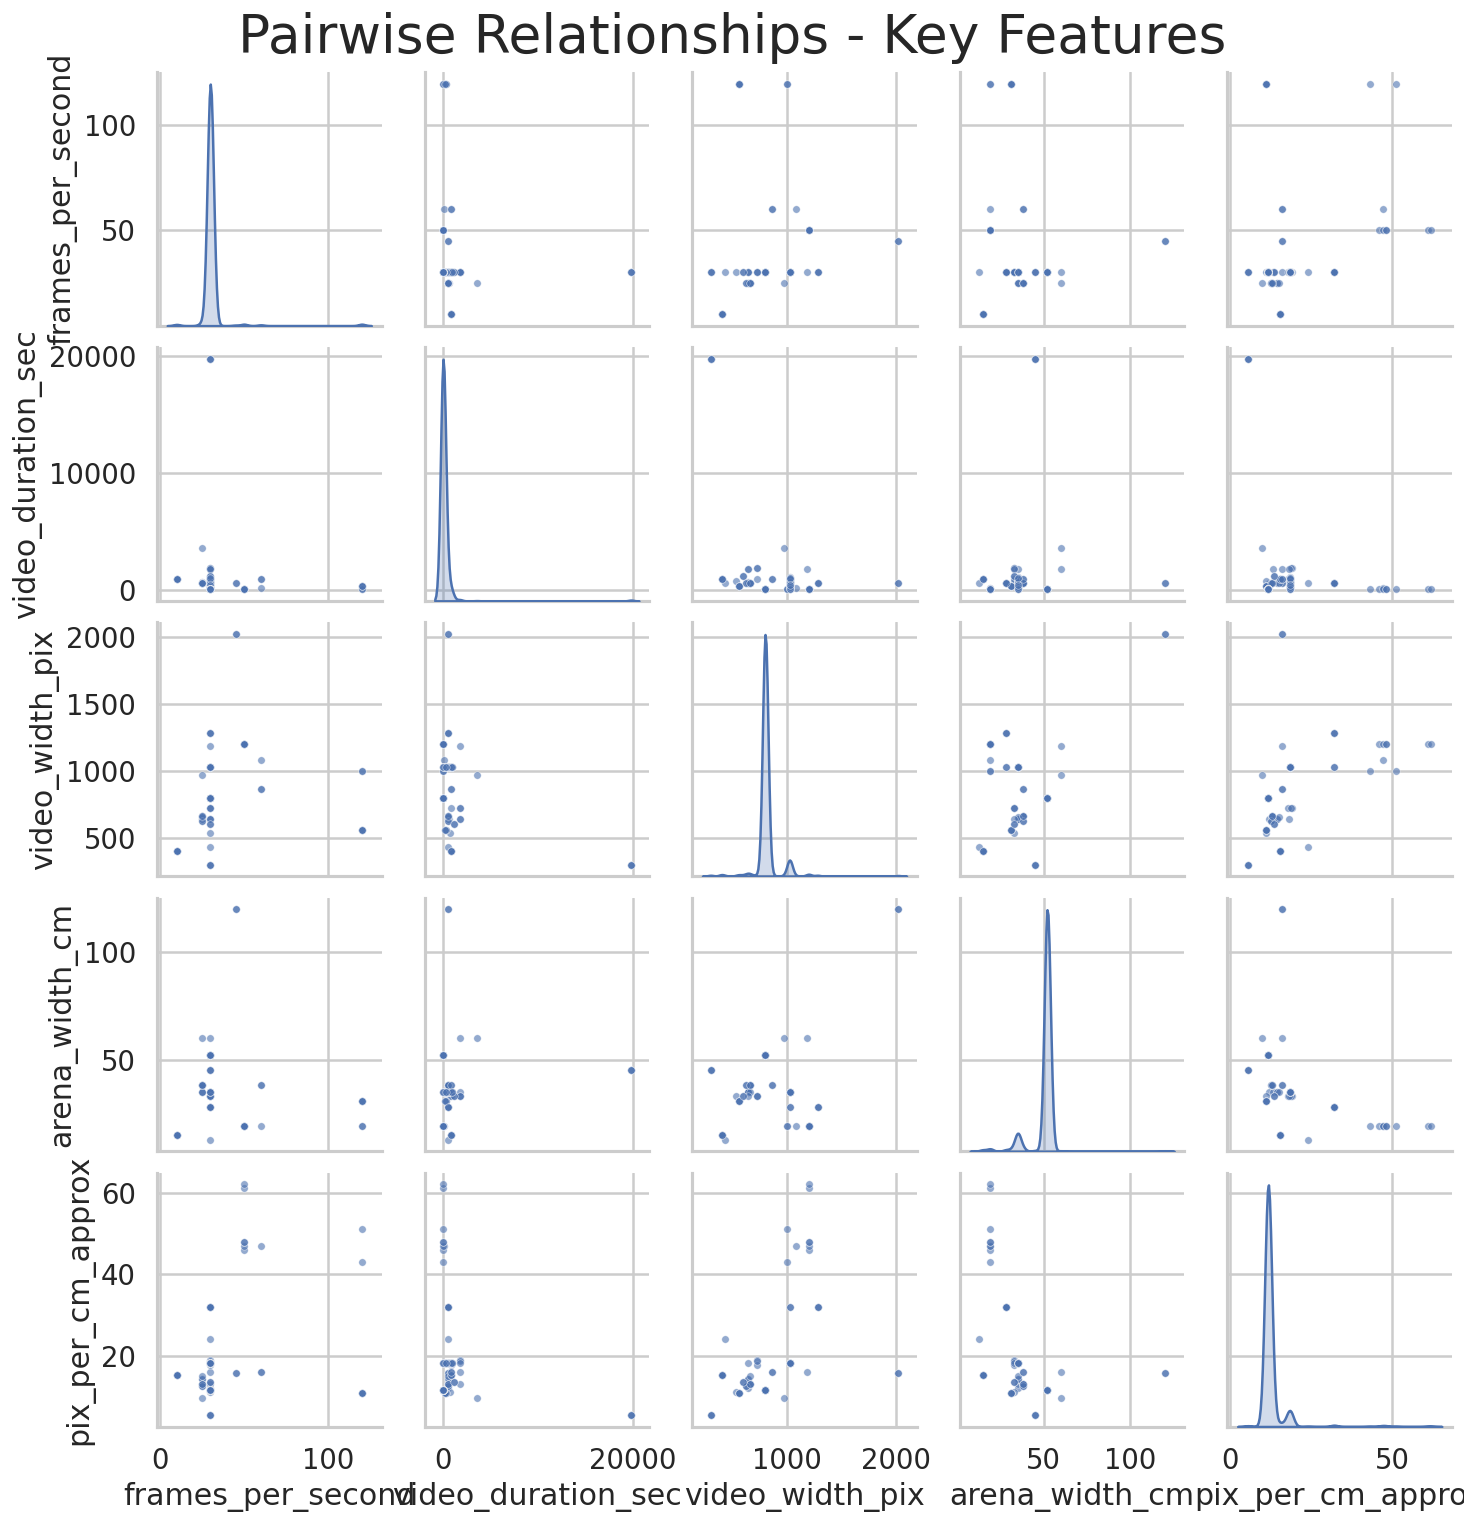

In [17]:
# Pair plot for key numeric features
key_features = ['frames_per_second', 'video_duration_sec', 'video_width_pix', 
                'arena_width_cm', 'pix_per_cm_approx']
key_features = [f for f in key_features if f in train.columns]

if len(key_features) >= 3:
    sample_size = min(1000, len(train))
    sample_data = train[key_features].sample(n=sample_size, random_state=42)

    pair_plot = sns.pairplot(sample_data, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 20})
    pair_plot.figure.suptitle('Pairwise Relationships - Key Features', y=1.02, size=32)
    plt.savefig(figures_dir / "pairplot_key_features.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

## 14. Data Quality Score Card


DATA QUALITY SCORE CARD
Total Records........................... 8789
Complete Records........................ 3
Completeness (%)........................ 0.03
Duplicate Records....................... 0
Unique Labs............................. 21
Unique Videos........................... 8789
Unique Mice (approx).................... 80
Numeric Columns......................... 13
Categorical Columns..................... 26
Missing Cell %.......................... 27.13


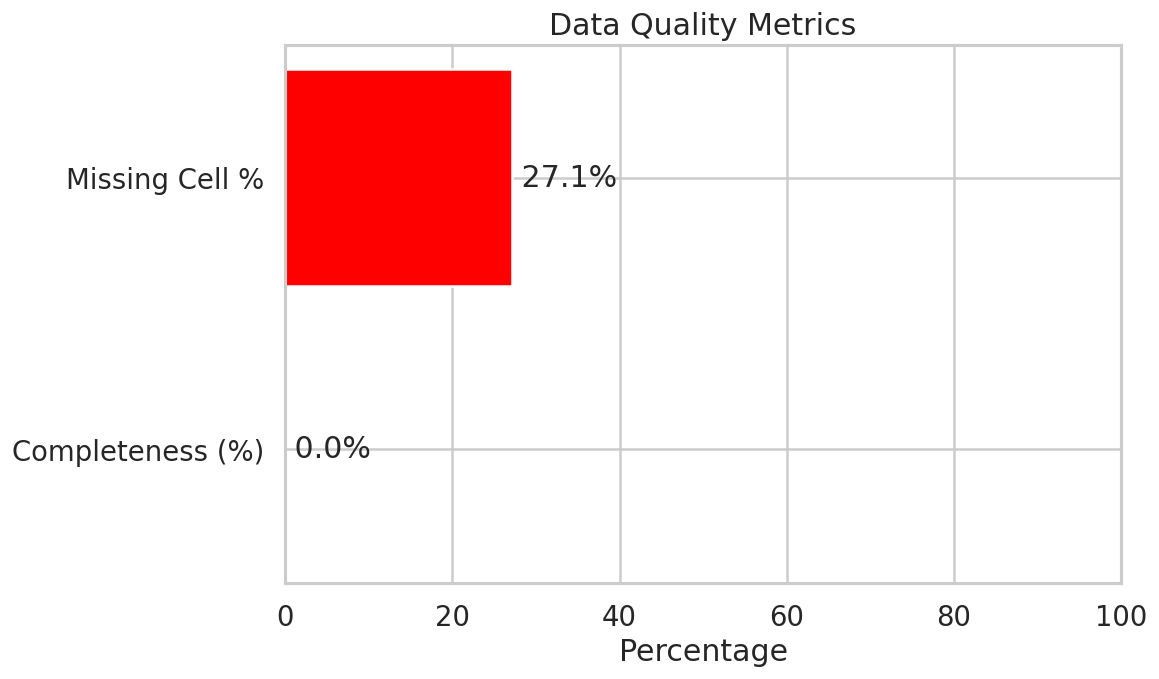

In [18]:
# Comprehensive data quality assessment
quality_metrics = {
    'Total Records': len(train),
    'Complete Records': len(train.dropna()),
    'Completeness (%)': (len(train.dropna()) / len(train) * 100),
    'Duplicate Records': train.duplicated().sum(),
    'Unique Labs': train['lab_id'].nunique(),
    'Unique Videos': train['video_id'].nunique(),
    'Unique Mice (approx)': len(set([id for col in [f'mouse{i}_id' for i in range(1, 5)] 
                                      if col in train.columns 
                                      for id in train[col].dropna()])),
    'Numeric Columns': len(train.select_dtypes(include=[np.number]).columns),
    'Categorical Columns': len(train.select_dtypes(include=['object']).columns),
    'Missing Cell %': (train.isnull().sum().sum() / (train.shape[0] * train.shape[1]) * 100)
}

print("\n" + "=" * 80)
print("DATA QUALITY SCORE CARD")
print("=" * 80)
for metric, value in quality_metrics.items():
    if isinstance(value, float):
        print(f"{metric:.<40} {value:.2f}")
    else:
        print(f"{metric:.<40} {value}")

# Create quality score visualization
fig, ax = plt.subplots(figsize=(10, 6))
metrics_to_plot = ['Completeness (%)', 'Missing Cell %']
values = [quality_metrics['Completeness (%)'], quality_metrics['Missing Cell %']]
colors = ['green' if v > 80 else 'orange' if v > 60 else 'red' for v in values]

bars = ax.barh(metrics_to_plot, values, color=colors)
ax.set_xlabel('Percentage')
ax.set_title('Data Quality Metrics')
ax.set_xlim(0, 100)

for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(val, i, f' {val:.1f}%', va='center')

plt.tight_layout()
plt.savefig(figures_dir / "data_quality_scorecard.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 15. Summary Report

In [19]:
print("\n" + "=" * 80)
print("COMPREHENSIVE EDA SUMMARY")
print("=" * 80)

summary = f"""
DATASET OVERVIEW:
- Training records: {len(train):,}
- Test records: {len(test):,}
- Total features: {train.shape[1]}
- Numeric features: {len(train.select_dtypes(include=[np.number]).columns)}
- Categorical features: {len(train.select_dtypes(include=['object']).columns)}

KEY FINDINGS:
1. Lab Distribution: {train['lab_id'].nunique()} unique labs
   - Largest: {train['lab_id'].value_counts().index[0]} ({train['lab_id'].value_counts().iloc[0]:,} videos)
   - Smallest: {train['lab_id'].value_counts().index[-1]} ({train['lab_id'].value_counts().iloc[-1]:,} videos)

2. Video Properties:
   - Average duration: {train['video_duration_sec'].mean():.1f} seconds
   - Most common FPS: {train['frames_per_second'].mode().values[0]:.0f}
   - Most common resolution: {train['video_width_pix'].mode().values[0]:.0f}x{train['video_height_pix'].mode().values[0]:.0f}

3. Experimental Setup:
   - Arena types: {train['arena_type'].nunique()}
   - Arena shapes: {train['arena_shape'].nunique()}
   - Tracking methods: {train['tracking_method'].nunique()}

4. Mouse Subjects:
   - Approximate unique mice: {quality_metrics['Unique Mice (approx)']}
   - Most common strain: {pd.Series([s for col in [f'mouse{i}_strain' for i in range(1, 5)] if col in train.columns for s in train[col].dropna()]).mode().values[0]}
   - Most common sex: {pd.Series([s for col in [f'mouse{i}_sex' for i in range(1, 5)] if col in train.columns for s in train[col].dropna()]).mode().values[0]}

5. Data Quality:
   - Completeness: {quality_metrics['Completeness (%)']:.1f}%
   - Missing data: {quality_metrics['Missing Cell %']:.1f}%
   - Duplicates: {quality_metrics['Duplicate Records']}

RECOMMENDATIONS:
✓ Handle missing data in mouse4 columns (appears to be 3-mouse experiments)
✓ Consider lab-specific normalization due to protocol differences
✓ Investigate high correlation between mouse IDs for feature engineering
✓ Analyze temporal patterns in behavior annotations
✓ Create interaction features from tracking data
✓ Consider stratified sampling by lab for train/val splits
"""

print(summary)

# Save summary to file
with open(figures_dir.parent / "eda_summary_report.txt", 'w') as f:
    f.write(summary)

print(f"\n{'='*80}")
print(f"✅ COMPREHENSIVE EDA COMPLETE")
print(f"{'='*80}")
print(f"📊 Total figures generated: ~15-20 high-quality visualizations")
print(f"📁 All outputs saved to: {figures_dir.absolute()}")
print(f"📄 Summary report saved to: {(figures_dir.parent / 'eda_summary_report.txt').absolute()}")


COMPREHENSIVE EDA SUMMARY

DATASET OVERVIEW:
- Training records: 8,789
- Test records: 1
- Total features: 39
- Numeric features: 13
- Categorical features: 26

KEY FINDINGS:
1. Lab Distribution: 21 unique labs
   - Largest: MABe22_keypoints (5,320 videos)
   - Smallest: DeliriousFly (6 videos)

2. Video Properties:
   - Average duration: 134.6 seconds
   - Most common FPS: 30
   - Most common resolution: 800x800

3. Experimental Setup:
   - Arena types: 5
   - Arena shapes: 4
   - Tracking methods: 4

4. Mouse Subjects:
   - Approximate unique mice: 80
   - Most common strain: C57Bl/6J
   - Most common sex: male

5. Data Quality:
   - Completeness: 0.0%
   - Missing data: 27.1%
   - Duplicates: 0

RECOMMENDATIONS:
✓ Handle missing data in mouse4 columns (appears to be 3-mouse experiments)
✓ Consider lab-specific normalization due to protocol differences
✓ Investigate high correlation between mouse IDs for feature engineering
✓ Analyze temporal patterns in behavior annotations
✓ Creat